# Aspect-Based Sentiment Analysis (ABSA) Pipeline
## Fine-Tuning Qwen2.5-1.5B-Instruct on SemEval Laptop Reviews

**Model:** `Qwen/Qwen2.5-1.5B-Instruct`  
**Task:** Extract aspects and assign sentiments from laptop reviews  
**Method:** Instruction fine-tuning with LoRA/PEFT  
**Output:** Structured JSON validated via Pydantic

---
### What this notebook does
Given a product review like:
> *"The battery life is amazing but the screen is dim."*

The model learns to output structured JSON:
```json
{"aspects": [{"term": "battery life", "sentiment": "positive"}, {"term": "screen", "sentiment": "negative"}]}
```


## 1. Environment Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ─── Install all required packages ────────────────────────────────────────────
!pip install -q \
  transformers==4.41.2 \
  peft==0.11.1 \
  trl==0.10.1 \
  accelerate==0.30.1 \
  datasets==2.19.0 \
  pydantic==2.7.1 \
  scikit-learn \
  matplotlib \
  seaborn \
  pandas==2.2.2 \
  numpy==1.26.4 \
  sentencepiece \
  protobuf

print("All packages installed")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.3/107.3 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.1/280.1 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.3/409.3 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
!pip uninstall -y numpy pandas

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2


In [2]:
!pip install -q numpy==1.26.4
!pip install -q pandas==2.2.2 --no-cache-dir --force-reinstall
print("Done")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 2.19.0 requires pandas, which is not installed.
plotnine 0.14.5 requires pandas>=2.2.0, which is not installed.
geemap 0.37.2 requires pandas, which is not installed.
pymc 5.28.4 requires pandas>=0.24.0, which is not installed.
holoviews 1.22.1 requires pandas>=1.3, which is not installed.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, which is not installed.
prophet 1.3.0 requires pandas>=1.0.4, which is not installed.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, which is not installed.
esda 2.9.0 requires pandas>=2.1, which is not installed.
segregation 2.5.4 requires pandas, which is not installed.
pandas-gbq 0.30.0 requires pandas>=1.1.4, which is not installed.
dopamine-rl 4.1.2 requires pandas>=0.24.2, which is not installed.
mizani 0.13.5 requires pandas>=2.2.0, which is not installed.
spreg 1

## 2. Imports & Global Configuration



In [1]:
import os, re, json, random, warnings, logging
from pathlib import Path
from typing import List, Optional, Dict, Any, Tuple
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    TrainerCallback,
    GenerationConfig,
    set_seed,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from trl import SFTTrainer
from datasets import Dataset as HFDataset, DatasetDict, load_from_disk
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from pydantic import BaseModel, field_validator, ValidationError

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)

# ─── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
set_seed(SEED); random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ─── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR   = Path("/content/drive/MyDrive/NLU_Finetuning")
DATA_DIR   = BASE_DIR / "data"
MODEL_DIR  = BASE_DIR / "model"
OUTPUT_DIR = BASE_DIR / "outputs"
PLOT_DIR   = BASE_DIR / "plots"
for d in [DATA_DIR, MODEL_DIR, OUTPUT_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MODEL_ID          = str(MODEL_DIR)
FINE_TUNED_DIR    = str(MODEL_DIR / "qwen_absa_lora")
MAX_SEQ_LEN       = 256
SENTIMENT_CLASSES = ["positive", "negative", "neutral", "conflict"]

# ─── Training hyperparameters ─────────────────────────────────────────────────
TRAIN_CONFIG = {
    "learning_rate"               : 1e-4,
    "per_device_train_batch_size" : 1,
    "per_device_eval_batch_size"  : 2,
    "gradient_accumulation_steps" : 4,
    "num_train_epochs"            : 2,
    "warmup_steps"                : 0,
    "weight_decay"                : 0.01,
    "max_grad_norm"               : 1.0,
    "lr_scheduler_type"           : "cosine",
    "logging_steps"               : 5,
    "eval_steps"                  : 50,
    "save_steps"                  : 50,
    "fp16"                        : False,
}

# ─── LoRA configuration ───────────────────────────────────────────────────────
LORA_CONFIG = {
    "r"              : 16,
    "lora_alpha"     : 32,
    "lora_dropout"   : 0.05,
    "target_modules" : ["q_proj","k_proj","v_proj","o_proj",
                        "gate_proj","up_proj","down_proj"],
    "bias"           : "none",
    "task_type"      : TaskType.CAUSAL_LM,
    "inference_mode" : False,
}

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


Device: cuda
   GPU : Tesla T4
   VRAM: 15.6 GB


## 3. Pydantic Schema for Output Validation

We define a strict schema that every model output must conform to.  
This guarantees structured, type-safe results throughout the pipeline.


In [2]:
# ─── Pydantic schema definitions ──────────────────────────────────────────────
class AspectSentiment(BaseModel):
    """Single aspect-sentiment pair."""
    term     : str
    sentiment: str

    @field_validator("sentiment")
    @classmethod
    def sentiment_must_be_valid(cls, v: str) -> str:
        v = v.strip().lower()
        if v not in SENTIMENT_CLASSES:
            raise ValueError(
                f"Invalid sentiment '{v}'. "
                f"Must be one of: {SENTIMENT_CLASSES}"
            )
        return v

    @field_validator("term")
    @classmethod
    def term_must_be_non_empty(cls, v: str) -> str:
        v = v.strip()
        if not v:
            raise ValueError("Aspect term cannot be empty.")
        return v


class ABSAOutput(BaseModel):
    """Top-level schema for ABSA model output."""
    aspects: List[AspectSentiment]

    @field_validator("aspects")
    @classmethod
    def aspects_must_be_non_empty_list(cls, v: List[AspectSentiment]):
        # Allow empty list for reviews with no detectable aspects
        return v

In [3]:
# ─── FINAL VALIDATOR ───────────────────────────────────────────────────────────

def validate_output(raw: str) -> Optional[ABSAOutput]:
    raw = raw.strip()

    # Remove markdown
    raw = re.sub(r"^```(?:json)?\s*", "", raw)
    raw = re.sub(r"\s*```$", "", raw)

    # Find first JSON object
    start = raw.find("{")
    if start == -1:
        return None

    # Extract balanced JSON
    brace_count = 0
    end = start

    for i in range(start, len(raw)):
        if raw[i] == "{":
            brace_count += 1
        elif raw[i] == "}":
            brace_count -= 1

        if brace_count == 0:
            end = i + 1
            break

    candidate = raw[start:end]

    # Fix trailing commas
    candidate = re.sub(r",\s*}", "}", candidate)
    candidate = re.sub(r",\s*]", "]", candidate)

    try:
        data = json.loads(candidate)
        return ABSAOutput(**data)
    except (json.JSONDecodeError, ValidationError, TypeError):
        return None

In [4]:
# ──────────────────────────────────────────────────────────────────────────────
# DEBUG VERSION OF NEW VALIDATOR (PRINTS EVERYTHING)
# ──────────────────────────────────────────────────────────────────────────────

test_cases = [
    ('{"aspects":[{"term":"battery","sentiment":"positive"}]}', True),
    ('{"aspects":[{"term":"screen","sentiment":"NEGATIVE"}]}',  True),
    ('{"aspects":[]}',                                          True),
    ('{"aspects":[{"term":"","sentiment":"positive"}]}',        False),
    ('{"aspects":[{"term":"cpu","sentiment":"amazing"}]}',      False),
    ('Not JSON at all',                                         False),

    # Edge cases
    ('{"aspects":[{"term":"battery","sentiment":"positive"},]}', True),
    ('text {"aspects":[{"term":"screen","sentiment":"negative"}]} extra', True),
    ('Here is result: {"aspects":[{"term":"ram","sentiment":"positive"}]}', True),
    ("""```json
    {"aspects":[{"term":"keyboard","sentiment":"negative"}]}
    ```""", True),
    ('{"aspects":[{"term":"cpu","sentiment":"positive"}, {"term":"fan","sentiment":"negative"},]}', True),
    ('{"aspects":[{"term":"screen","sentiment":"negative"}]} explanation', True),
    ("""
    {
      "aspects": [
        {"term": "battery", "sentiment": "positive"},
      ]
    }
    """, True),
]

def validate_output_new_debug(raw: str) -> Optional[ABSAOutput]:
    print("\n" + "="*70)
    print("🔹 ORIGINAL RAW:")
    print(raw)

    raw = raw.strip()

    # Remove markdown
    cleaned = re.sub(r"^```(?:json)?\s*", "", raw)
    cleaned = re.sub(r"\s*```$", "", cleaned)

    print("\n🔹 AFTER CLEANING:")
    print(cleaned)

    # Step 1: find first '{'
    start = cleaned.find("{")
    if start == -1:
        print("\n❌ No JSON found")
        return None

    # Step 2: extract balanced JSON
    brace_count = 0
    end = start

    for i in range(start, len(cleaned)):
        if cleaned[i] == "{":
            brace_count += 1
        elif cleaned[i] == "}":
            brace_count -= 1

        if brace_count == 0:
            end = i + 1
            break

    candidate = cleaned[start:end]

    print("\n🔹 EXTRACTED JSON:")
    print(candidate)

    # Fix trailing commas
    fixed = re.sub(r",\s*}", "}", candidate)
    fixed = re.sub(r",\s*]", "]", fixed)

    print("\n🔹 AFTER FIXING:")
    print(fixed)

    # Try parsing
    try:
        data = json.loads(fixed)
        print("\n🔹 PARSED JSON:")
        print(data)
    except Exception as e:
        print("\n❌ JSON PARSE ERROR:", e)
        return None

    # Validate schema
    try:
        validated = ABSAOutput(**data)
        print("\n✅ FINAL VALIDATED OUTPUT:")
        print(validated.model_dump())
        return validated
    except Exception as e:
        print("\n❌ PYDANTIC VALIDATION ERROR:", e)
        return None


# ──────────────────────────────────────────────────────────────────────────────
# RUN DEBUG ON TEST CASES
# ──────────────────────────────────────────────────────────────────────────────

print("===== DEBUG RUN =====")

for i, (raw, _) in enumerate(test_cases):
    print(f"\n\n --- TEST {i} ---")
    result = validate_output_new_debug(raw)
    print("RESULT:", "✅ VALID" if result else "❌ INVALID")

===== DEBUG RUN =====


 --- TEST 0 ---

🔹 ORIGINAL RAW:
{"aspects":[{"term":"battery","sentiment":"positive"}]}

🔹 AFTER CLEANING:
{"aspects":[{"term":"battery","sentiment":"positive"}]}

🔹 EXTRACTED JSON:
{"aspects":[{"term":"battery","sentiment":"positive"}]}

🔹 AFTER FIXING:
{"aspects":[{"term":"battery","sentiment":"positive"}]}

🔹 PARSED JSON:
{'aspects': [{'term': 'battery', 'sentiment': 'positive'}]}

✅ FINAL VALIDATED OUTPUT:
{'aspects': [{'term': 'battery', 'sentiment': 'positive'}]}
RESULT: ✅ VALID


 --- TEST 1 ---

🔹 ORIGINAL RAW:
{"aspects":[{"term":"screen","sentiment":"NEGATIVE"}]}

🔹 AFTER CLEANING:
{"aspects":[{"term":"screen","sentiment":"NEGATIVE"}]}

🔹 EXTRACTED JSON:
{"aspects":[{"term":"screen","sentiment":"NEGATIVE"}]}

🔹 AFTER FIXING:
{"aspects":[{"term":"screen","sentiment":"NEGATIVE"}]}

🔹 PARSED JSON:
{'aspects': [{'term': 'screen', 'sentiment': 'NEGATIVE'}]}

✅ FINAL VALIDATED OUTPUT:
{'aspects': [{'term': 'screen', 'sentiment': 'negative'}]}
RESULT: ✅ VALI

## 4. Data Loading & Preprocessing

We use the **SemEval-2014 Task 4 Laptop Reviews** dataset.  
The pipeline:
1. Downloads the dataset.
3. Groups by sentence → aggregates all aspects per review
4. Builds the canonical `{"text": "...", "aspects": [...]}` format


In [5]:
# ─── Load data ─────────────────────────────────────────────────────────────────
CSV_PATH = DATA_DIR / "Laptop_Train_v2.csv"
raw_df = pd.read_csv(CSV_PATH)

print(f"Dataset shape: {raw_df.shape}")
print("Columns:", raw_df.columns.tolist())

raw_df.head()

Dataset shape: (2358, 6)
Columns: ['id', 'Sentence', 'Aspect Term', 'polarity', 'from', 'to']


,id,Sentence,Aspect Term,polarity,from,to
0,2339,I charge it at night and skip taking the cord ...,cord,neutral,41,45
1,2339,I charge it at night and skip taking the cord ...,battery life,positive,74,86
2,1316,The tech guy then said the service center does...,service center,negative,27,41
3,1316,The tech guy then said the service center does...,"""sales"" team",negative,109,121
4,1316,The tech guy then said the service center does...,tech guy,neutral,4,12


In [6]:
# ─── Data Cleaning & Schema Standardization ───────────────────────────────────
raw_df.columns = [c.lower().replace(" ", "_") for c in raw_df.columns]


raw_df.rename(columns={
    "id": "sentence_id",
    "text": "sentence",
    "aspect_term": "aspect_term",
    "polarity": "polarity"
}, inplace=True)

# Ensure aspect_term exists
if "aspect_term" not in raw_df.columns and "term" in raw_df.columns:
    raw_df.rename(columns={"term": "aspect_term"}, inplace=True)

# Normalise polarity labels
raw_df["polarity"] = raw_df["polarity"].str.lower().str.strip()
raw_df = raw_df[raw_df["polarity"].isin(SENTIMENT_CLASSES)]

print(f"\nRaw dataset shape: {raw_df.shape}")
print(f"   Sentiment distribution:")
print(raw_df["polarity"].value_counts().to_string(header=False))

raw_df.head()


Raw dataset shape: (2358, 6)
   Sentiment distribution:
positive    987
negative    866
neutral     460
conflict     45


,sentence_id,sentence,aspect_term,polarity,from,to
0,2339,I charge it at night and skip taking the cord ...,cord,neutral,41,45
1,2339,I charge it at night and skip taking the cord ...,battery life,positive,74,86
2,1316,The tech guy then said the service center does...,service center,negative,27,41
3,1316,The tech guy then said the service center does...,"""sales"" team",negative,109,121
4,1316,The tech guy then said the service center does...,tech guy,neutral,4,12


In [7]:
# ─── Group by sentence → aggregate aspects ────────────────────────────────────

def aggregate_aspects(df: pd.DataFrame) -> pd.DataFrame:
    """
    Group a flat DataFrame by (sentence_id, sentence) and
    aggregate all aspect-term/polarity pairs into a list.

    Returns a DataFrame with columns:
        sentence_id | sentence | aspects
    where `aspects` is a list of dicts: [{"term": ..., "sentiment": ...}]
    """
    agg_rows = []
    group_cols = ["sentence_id", "sentence"]

    for keys, group in df.groupby(group_cols, sort=False):
        sid, sentence = keys

        aspects = [
            {"term": row["aspect_term"], "sentiment": row["polarity"]}
            for _, row in group.iterrows()
            if row["aspect_term"].strip()
        ]
        # Deduplicate (keep first occurrence per term)
        seen, deduped = set(), []
        for a in aspects:
            key = (a["term"].lower(), a["sentiment"])
            if key not in seen:
                seen.add(key)
                deduped.append(a)

        agg_rows.append({
            "sentence_id": sid,
            "text"       : sentence,
            "aspects"    : deduped,
        })

    return pd.DataFrame(agg_rows)


agg_df = aggregate_aspects(raw_df)

In [8]:
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

SENTIMENT_CLASSES = ["positive", "negative", "neutral", "conflict"]

def build_review_signature(aspects):
    """
    Build a stratification key from the sentiment composition of one review.
    Example:
        2 positive, 1 negative, 0 neutral, 0 conflict -> 'p2_n1_u0_c0'
    """
    counts = Counter(a["sentiment"] for a in aspects)
    return f"p{counts.get('positive', 0)}_n{counts.get('negative', 0)}_u{counts.get('neutral', 0)}_c{counts.get('conflict', 0)}"


def stratified_review_split(agg_df: pd.DataFrame, seed: int = 42):
    """
    Split aggregated ABSA data into train/val/test with a better balance of
    sentiment composition across splits.

    Strategy:
    1) Build a signature for each review based on aspect sentiment counts.
    2) Merge very rare signatures into an 'other' bucket.
    3) Split 80/10/10 using stratification.
    """
    df = agg_df.copy()

    # Create review-level stratification keys
    df["stratify_key"] = df["aspects"].apply(build_review_signature)

    # Merge rare signatures to avoid stratify errors
    key_counts = df["stratify_key"].value_counts()
    rare_keys = key_counts[key_counts < 4].index  # adjust if needed

    df["stratify_key_safe"] = df["stratify_key"].apply(
        lambda x: "other" if x in rare_keys else x
    )

    # First split: 90% train+val, 10% test
    train_val_df, test_df = train_test_split(
        df,
        test_size=0.10,
        random_state=seed,
        shuffle=True,
        stratify=df["stratify_key_safe"]
    )

    # Second split: from the 90%, make 80/10 overall
    # Validation should be 10% of total, so it is 1/9 of the train_val part.
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=1/9,
        random_state=seed,
        shuffle=True,
        stratify=train_val_df["stratify_key_safe"]
    )

    # Clean up helper columns
    train_df = train_df.drop(columns=["stratify_key", "stratify_key_safe"]).reset_index(drop=True)
    val_df   = val_df.drop(columns=["stratify_key", "stratify_key_safe"]).reset_index(drop=True)
    test_df  = test_df.drop(columns=["stratify_key", "stratify_key_safe"]).reset_index(drop=True)

    return train_df, val_df, test_df


def get_sentiment_counts(df: pd.DataFrame) -> pd.Series:
    """
    Count aspect-level sentiment labels inside one split.
    """
    labels = [
        a["sentiment"]
        for aspects in df["aspects"]
        for a in aspects
    ]
    return pd.Series(labels).value_counts().reindex(SENTIMENT_CLASSES, fill_value=0)


def plot_split_distribution(train_df, val_df, test_df):
    """
    Draw and save a grouped bar chart showing the number of
    aspect-level sentiment samples in each split.
    """

    counts_df = pd.DataFrame({
        "Train": get_sentiment_counts(train_df),
        "Validation": get_sentiment_counts(val_df),
        "Test": get_sentiment_counts(test_df),
    })

    ax = counts_df.plot(
        kind="bar",
        figsize=(10, 6),
        rot=0
    )

    ax.set_title("Sentiment Distribution Across Splits",
                 fontsize=14,
                 fontweight="bold")

    ax.set_xlabel("Sentiment Class")
    ax.set_ylabel("Number of Aspect Samples")

    plt.legend(title="Split")
    plt.tight_layout()

    # ── Save plot ────────────────────────────────────────────────────────────
    save_path = PLOT_DIR / "split_sentiment_distribution.png"

    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print(f"\n📊 Plot saved to {save_path}")

    print("\nAspect-level sentiment counts per split:")
    print(counts_df)


# ── Use the enhanced split ───────────────────────────────────────────────────
train_df, val_df, test_df = stratified_review_split(agg_df, seed=SEED)

print(f"Train reviews: {len(train_df)}")
print(f"Val reviews  : {len(val_df)}")
print(f"Test reviews : {len(test_df)}")

print(f"\nTrain aspects: {train_df['aspects'].map(len).sum()}")
print(f"Val aspects  : {val_df['aspects'].map(len).sum()}")
print(f"Test aspects : {test_df['aspects'].map(len).sum()}")

Train reviews: 1190
Val reviews  : 149
Test reviews : 149

Train aspects: 1857
Val aspects  : 235
Test aspects : 229


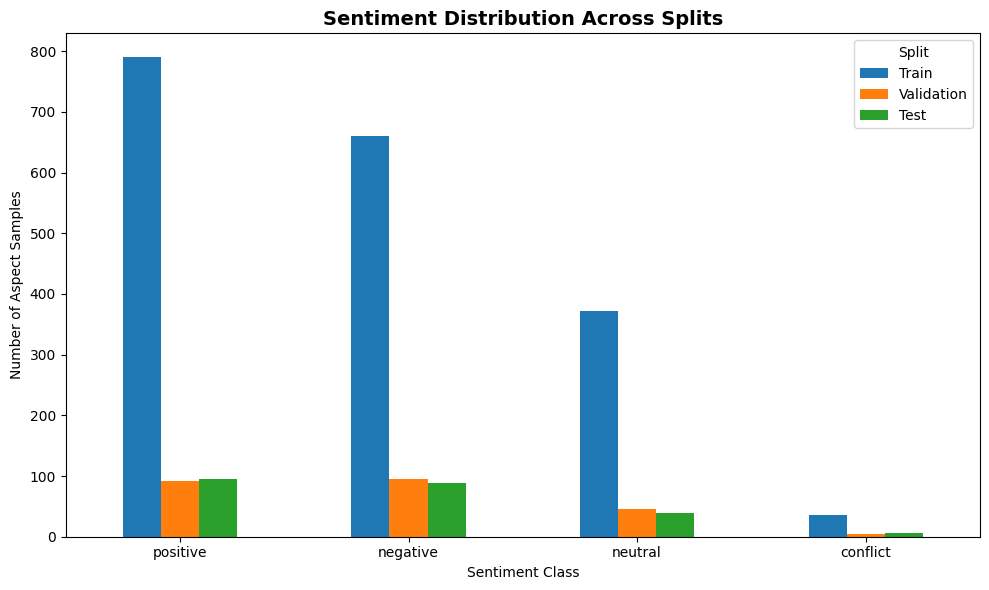


📊 Plot saved to /content/drive/MyDrive/NLU_Finetuning/plots/split_sentiment_distribution.png

Aspect-level sentiment counts per split:
          Train  Validation  Test
positive    790          91    95
negative    660          95    89
neutral     372          45    39
conflict     35           4     6


In [9]:
# ── Plot the diagram ─────────────────────────────────────────────────────────
plot_split_distribution(train_df, val_df, test_df)

In [14]:
print("Example record:")
ex = train_df.iloc[3]
print(f"  Text    : {ex['text']}")
print(f"  Aspects : {json.dumps(ex['aspects'], indent=2)}")

Example record:
  Text    : BUT there's this application called Boot Camp which allows you to add another OS X like Windows.
  Aspects : [
  {
    "term": "application",
    "sentiment": "neutral"
  },
  {
    "term": "OS X",
    "sentiment": "neutral"
  },
  {
    "term": "Boot Camp",
    "sentiment": "neutral"
  },
  {
    "term": "Windows",
    "sentiment": "neutral"
  }
]


In [ ]:
# # ─── Split into train / val / test 80/10/10 ────────────────────────────────────────────
# n = len(agg_df)
# indices = list(range(n))
# random.shuffle(indices)

# train_end = int(0.8 * n)
# val_end   = int(0.9 * n)

# train_df = agg_df.iloc[indices[:train_end]].reset_index(drop=True)
# val_df   = agg_df.iloc[indices[train_end:val_end]].reset_index(drop=True)
# test_df  = agg_df.iloc[indices[val_end:]].reset_index(drop=True)

# print(f"   Aggregated dataset:")
# print(f"   Train    : {len(train_df):>5,} reviews  ({train_df['aspects'].map(len).sum():,} aspects)")
# print(f"   Validation: {len(val_df):>4,} reviews  ({val_df['aspects'].map(len).sum():,} aspects)")
# print(f"   Test     : {len(test_df):>5,} reviews  ({test_df['aspects'].map(len).sum():,} aspects)")
# print()
# print("Example record:")
# ex = train_df.iloc[919]
# print(f"  Text    : {ex['text']}")
# print(f"  Aspects : {json.dumps(ex['aspects'], indent=2)}")

   Aggregated dataset:
   Train    : 1,190 reviews  (1,855 aspects)
   Validation:  149 reviews  (239 aspects)
   Test     :   149 reviews  (227 aspects)

Example record:
  Text    : Aside from the trial software and the short battery life, lack of a webcam, its great.
  Aspects : [
  {
    "term": "trial software",
    "sentiment": "negative"
  },
  {
    "term": "battery life",
    "sentiment": "negative"
  },
  {
    "term": "webcam",
    "sentiment": "negative"
  }
]


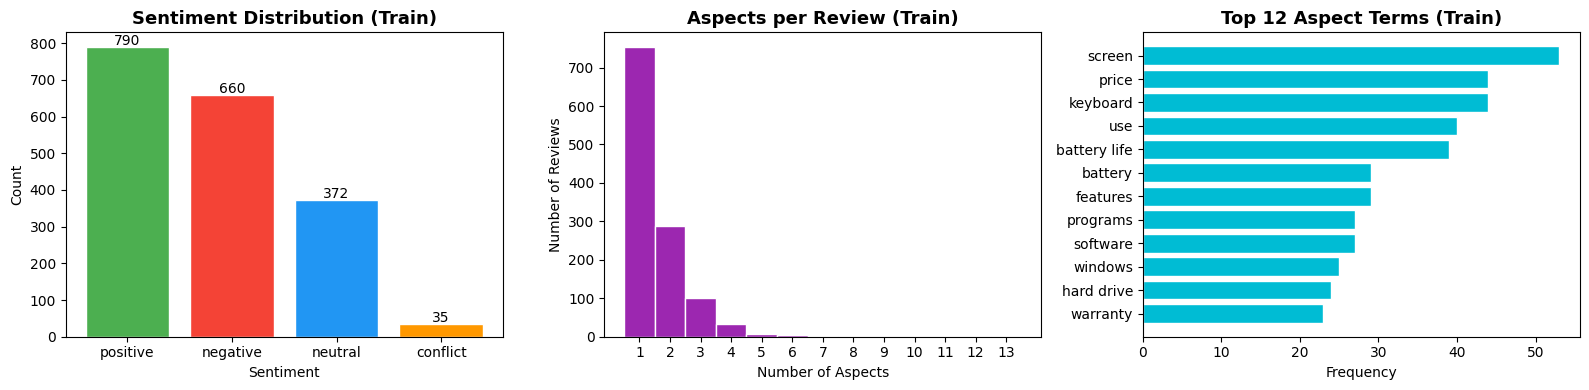


 EDA plots saved to /content/drive/MyDrive/NLU_Finetuning/plots/eda.png


In [15]:
# ─── Exploratory Data Analysis ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (1) Sentiment distribution in training set
all_sents = [a["sentiment"] for row in train_df["aspects"] for a in row]
sent_counts = pd.Series(all_sents).value_counts()
colors = ["#4CAF50", "#F44336", "#2196F3", "#FF9800"]
axes[0].bar(sent_counts.index, sent_counts.values, color=colors[:len(sent_counts)], edgecolor="white")
axes[0].set_title("Sentiment Distribution (Train)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
for i, v in enumerate(sent_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=10)

# (2) Aspects per review distribution
asp_counts = train_df["aspects"].map(len)
axes[1].hist(asp_counts, bins=range(1, asp_counts.max() + 2), color="#9C27B0",
             edgecolor="white", align="left")
axes[1].set_title("Aspects per Review (Train)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Aspects")
axes[1].set_ylabel("Number of Reviews")
axes[1].set_xticks(range(1, asp_counts.max() + 1))

# (3) Top aspect terms
all_terms = [a["term"].lower() for row in train_df["aspects"] for a in row]
term_freq  = pd.Series(all_terms).value_counts().head(12)
axes[2].barh(term_freq.index[::-1], term_freq.values[::-1], color="#00BCD4", edgecolor="white")
axes[2].set_title("Top 12 Aspect Terms (Train)", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Frequency")

plt.tight_layout()
plt.savefig(PLOT_DIR / "eda.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n EDA plots saved to {PLOT_DIR / 'eda.png'}")

In [16]:
# Flatten all aspects with their sentence
rows = []

for _, row in train_df.iterrows():
    text = row["text"]
    for a in row["aspects"]:
        rows.append({
            "text": text,
            "term": a["term"],
            "sentiment": a["sentiment"]
        })

flat_df = pd.DataFrame(rows)

# Print 5 samples per sentiment
for sentiment in SENTIMENT_CLASSES:
    print(f"\n===== {sentiment.upper()} SAMPLES =====")

    samples = flat_df[flat_df["sentiment"] == sentiment].head(2)

    for i, r in samples.iterrows():
        print(f"\nText: {r['text']}")
        print(f"Aspect: {r['term']}")
        print(f"Sentiment: {r['sentiment']}")


===== POSITIVE SAMPLES =====

Text: The battery life is also relatively good.
Aspect: battery life
Sentiment: positive

Text: I finally decided on this laptop because it was the right price for what I need it.
Aspect: price
Sentiment: positive

===== NEGATIVE SAMPLES =====

Text: Hmmm - that high failure rate sure isn't reflected in the retail price.
Aspect: retail price
Sentiment: negative

Text: Three weeks after I bought the netbook, the screen quit working.
Aspect: screen
Sentiment: negative

===== NEUTRAL SAMPLES =====

Text: BUT there's this application called Boot Camp which allows you to add another OS X like Windows.
Aspect: application
Sentiment: neutral

Text: BUT there's this application called Boot Camp which allows you to add another OS X like Windows.
Aspect: OS X
Sentiment: neutral

===== CONFLICT SAMPLES =====

Text: I will never complain about the price since I believe you get what you pay for and my MacBook Pro was worth every dollar.
Aspect: price
Sentiment: confli

---

*Neutral and conflict sentiments are fundamentally different, as neutral expresses no clear opinion while conflict reflects both positive and negative opinions simultaneously, so combining them leads to loss of important semantic information and weakens the model’s ability to capture nuanced sentiment.*

---

### - Handle class imbalance: oversample 'conflict' in the TRAIN split ONLY

In [17]:
def oversample_conflict_df(df: pd.DataFrame, repeat: int = 3) -> pd.DataFrame:
    """
    Oversample rows that contain at least one conflict aspect.
    """

    # Select rows that contain conflict
    conflict_mask = df["aspects"].apply(
        lambda aspects: any(a["sentiment"] == "conflict" for a in aspects)
    )

    conflict_df = df[conflict_mask]

    # Repeat conflict rows
    oversampled_conflict = pd.concat([conflict_df] * (repeat - 1), ignore_index=True)

    # Combine with original data
    df_balanced = pd.concat([df, oversampled_conflict], ignore_index=True)

    # Shuffle
    df_balanced = df_balanced.sample(frac=1, random_state=SEED).reset_index(drop=True)

    return df_balanced

train_balanced = oversample_conflict_df(train_df, repeat=3)

In [18]:
def count_conflict(df):
    return df["aspects"].apply(
        lambda aspects: any(a["sentiment"] == "conflict" for a in aspects)
    ).sum()

conflict_before = count_conflict(train_df)
conflict_after  = count_conflict(train_balanced)

print(f"Train samples before oversampling : {len(train_df)}")
print(f"Train samples after  oversampling : {len(train_balanced)}")
print(f"Conflict sentences before         : {conflict_before}")
print(f"Conflict sentences after          : {conflict_after}")

Train samples before oversampling : 1190
Train samples after  oversampling : 1258
Conflict sentences before         : 34
Conflict sentences after          : 102


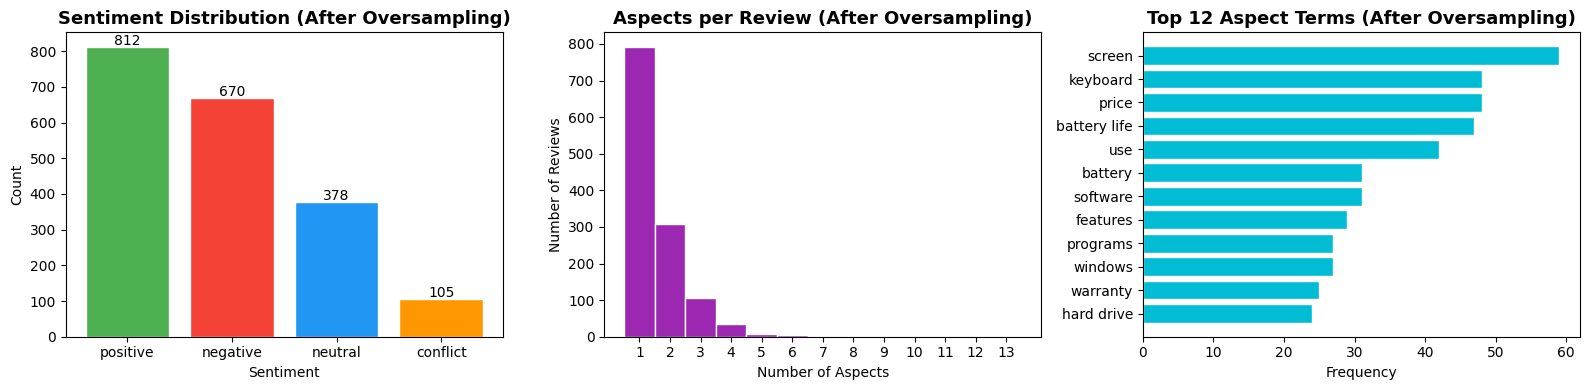


 EDA plots saved to /content/drive/MyDrive/NLU_Finetuning/plots/eda_after_oversampling.png


In [19]:
# ─── Exploratory Data Analysis (AFTER OVERSAMPLING) ────────────────────────────

eda_df = train_balanced   # use balanced dataset

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# SAME COLORS
colors = ["#4CAF50", "#F44336", "#2196F3", "#FF9800"]

# (1) Sentiment distribution
all_sents = [a["sentiment"] for row in eda_df["aspects"] for a in row]
sent_counts = pd.Series(all_sents).value_counts()

axes[0].bar(sent_counts.index, sent_counts.values,
            color=colors[:len(sent_counts)], edgecolor="white")

axes[0].set_title("Sentiment Distribution (After Oversampling)",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")

for i, v in enumerate(sent_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=10)

# (2) Aspects per review
asp_counts = eda_df["aspects"].map(len)

axes[1].hist(asp_counts,
             bins=range(1, asp_counts.max() + 2),
             color="#9C27B0",
             edgecolor="white",
             align="left")

axes[1].set_title("Aspects per Review (After Oversampling)",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Aspects")
axes[1].set_ylabel("Number of Reviews")
axes[1].set_xticks(range(1, asp_counts.max() + 1))

# (3) Top aspect terms
all_terms = [a["term"].lower() for row in eda_df["aspects"] for a in row]
term_freq = pd.Series(all_terms).value_counts().head(12)

axes[2].barh(term_freq.index[::-1],
             term_freq.values[::-1],
             color="#00BCD4",
             edgecolor="white")

axes[2].set_title("Top 12 Aspect Terms (After Oversampling)",
                  fontsize=13, fontweight="bold")
axes[2].set_xlabel("Frequency")

plt.tight_layout()

plt.savefig(PLOT_DIR / "eda_after_oversampling.png",
            dpi=150, bbox_inches="tight")

plt.show()

print(f"\n EDA plots saved to {PLOT_DIR / 'eda_after_oversampling.png'}")

## 5. Tokenizer Setup

In [20]:
print(os.listdir(MODEL_DIR))

['model-00001-of-00002.safetensors', 'config.json', 'generation_config.json', 'model-00002-of-00002.safetensors', 'model.safetensors.index.json', 'tokenizer_config.json', 'special_tokens_map.json', 'added_tokens.json', 'vocab.json', 'merges.txt', 'tokenizer.json', 'qwen_absa_loraxxxxx', 'qwen_absa_lorax', 'qwen_absa_loraxxxxxxxxxxxx', 'Final_Version', 'qwen_absa_lora_5epochs', 'qwen_absa_lora']


In [21]:
# ─── Tokenizer ─────────────────────────────────────────────────────────────
print(f"Loading tokenizer from {MODEL_ID} ...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    padding_side="right",
    use_fast=False
)


tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id

tokenizer.truncation_side = "left"

print(f"Vocab size: {tokenizer.vocab_size}")
print(f"EOS token: {tokenizer.eos_token}")
print(f"PAD token: {tokenizer.pad_token}")

Loading tokenizer from /content/drive/MyDrive/NLU_Finetuning/model ...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Vocab size: 151643
EOS token: <|im_end|>
PAD token: <|im_end|>


## 6. Prompt Engineering



In [22]:
# ─── Prompt templates ──────────────────────────────────────────────────────────

SYSTEM_PROMPT = """You are an expert Aspect-Based Sentiment Analysis (ABSA) system.
Your ONLY job is to extract aspect terms from laptop reviews and assign a sentiment to each.

RULES:
1. Return ONLY a valid JSON object — no explanation, no markdown, no extra text.
2. The JSON must follow this exact schema:
   {"aspects": [{"term": "<aspect>", "sentiment": "<sentiment>"}]}
3. Valid sentiment values: positive | negative | neutral | conflict
4. "conflict" means the review expresses both positive and negative opinions about the same aspect.
5. Extract ALL mentioned aspects, even if the sentiment is neutral.
6. If no aspects are found, return: {"aspects": []}
7. Use lowercase for both term and sentiment.""".strip()

FEW_SHOT_EXAMPLES = [
    {
        "review": "The battery life is amazing and lasts all day, but the screen is quite dim.",
        "output": json.dumps({
            "aspects": [
                {"term": "battery life", "sentiment": "positive"},
                {"term": "screen",       "sentiment": "negative"},
            ]
        }, separators=(",", ":")),
    },
]


def build_prompt(review_text: str,
                 include_answer: bool = False,
                 answer: Optional[str] = None) -> str:
    """
    Construct a Qwen chat-format prompt.

    BUG FIXED: When include_answer=True the answer is now added as a proper
    ASSISTANT message so apply_chat_template wraps it in
        <|im_start|>assistant\n{answer}<|im_end|>
    This is what DataCollatorForCompletionOnlyLM looks for.

    Previously, the answer was appended to the USER message content, meaning
    the collator's response template was never found → silent zero-loss training.
    """
    few_shot_block = "\n".join(
        f"Review: {ex['review']}\nOutput: {ex['output']}"
        for ex in FEW_SHOT_EXAMPLES
    )
    user_content = (
        f"Examples:\n{few_shot_block}\n\n"
        f"Now analyze the following review:\n"
        f"Review: {review_text}\n"
        f"Output:"
    )

    messages = [
        {"role": "system",    "content": SYSTEM_PROMPT},
        {"role": "user",      "content": user_content},
    ]

    if include_answer and answer is not None:
        # ── Training mode: add answer as assistant turn ────────────────────────
        messages.append({"role": "assistant", "content": answer})
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )
    else:
        # ── Inference mode: let model fill the assistant turn ──────────────────
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )


def aspects_to_json_string(aspects: List[Dict]) -> str:
    """Convert a list of aspect dicts to a compact JSON string."""
    return json.dumps({"aspects": aspects}, ensure_ascii=False, separators=(",", ":"))


# ─── Preview ──────────────────────────────────────────────────────────────────
sample_review  = "The screen resolution is gorgeous, but the battery drains too fast."
sample_aspects = [{"term": "screen resolution", "sentiment": "positive"},
                  {"term": "battery",            "sentiment": "negative"}]

print("=" * 72)
print("INFERENCE PROMPT (add_generation_prompt=True):")
print("=" * 72)
print(build_prompt(sample_review))

print()
print("=" * 72)
print("TRAINING PROMPT (answer as assistant message):")
print("=" * 72)
full_training = build_prompt(sample_review, include_answer=True,
                             answer=aspects_to_json_string(sample_aspects))
print(full_training)

# Verify assistant token appears in training text
assert "<|im_start|>assistant" in full_training, \
    "❌ Assistant token missing from training prompt — collator will fail!"
print("\n✅ <|im_start|>assistant token confirmed in training text.")


INFERENCE PROMPT (add_generation_prompt=True):
<|im_start|>system
You are an expert Aspect-Based Sentiment Analysis (ABSA) system.
Your ONLY job is to extract aspect terms from laptop reviews and assign a sentiment to each.

RULES:
1. Return ONLY a valid JSON object — no explanation, no markdown, no extra text.
2. The JSON must follow this exact schema:
   {"aspects": [{"term": "<aspect>", "sentiment": "<sentiment>"}]}
3. Valid sentiment values: positive | negative | neutral | conflict
4. "conflict" means the review expresses both positive and negative opinions about the same aspect.
5. Extract ALL mentioned aspects, even if the sentiment is neutral.
6. If no aspects are found, return: {"aspects": []}
7. Use lowercase for both term and sentiment.<|im_end|>
<|im_start|>user
Examples:
Review: The battery life is amazing and lasts all day, but the screen is quite dim.
Output: {"aspects":[{"term":"battery life","sentiment":"positive"},{"term":"screen","sentiment":"negative"}]}

Now analyze

## 7. Dataset Transformation

Convert the aggregated DataFrame into HuggingFace `Dataset` objects with:
- `prompt`      : full instruction prompt (input to the model)
- `completion`  : target JSON string (model output to learn)
- `full_text`   : `prompt + completion` (what the tokenizer sees during training)


In [23]:
# ─── Dataset transformation with pre-computed token-level labels ──────────────
from transformers import DataCollatorWithPadding

IGNORE_INDEX = -100   # PyTorch cross-entropy ignores this label

def find_response_start(input_ids: List[int], template_ids: List[int]) -> int:
    """
    Find the LAST occurrence of template_ids in input_ids.
    Returns the index AFTER the template (i.e. where the answer starts).
    Returns -1 if not found.
    """
    n, m = len(input_ids), len(template_ids)
    for i in range(n - m, -1, -1):          # search from the end
        if input_ids[i:i+m] == template_ids:
            return i + m                    # first token of the answer
    return -1


def tokenize_with_labels(
    full_text: str,
    template_ids: List[int],
    max_length: int = MAX_SEQ_LEN,
) -> Optional[Dict]:
    """
    Tokenise a single training sample and build hard-masked labels.

    Labels are IGNORE_INDEX (-100) for every prompt token and equal to
    input_ids for every answer token.  No collator magic is needed.
    """
    enc = tokenizer(
        full_text,
        truncation   = True,
        max_length   = max_length,
        padding      = False,
        return_tensors = None,   # plain Python lists
    )
    input_ids      = enc["input_ids"]
    attention_mask = enc["attention_mask"]

    # Find where the answer starts (after <|im_start|>assistant\n)
    ans_start = find_response_start(input_ids, template_ids)

    if ans_start == -1:
        # Template not found (truncation cut it off) → skip this sample
        return None

    # Build labels: mask everything before the answer
    labels = [IGNORE_INDEX] * ans_start + input_ids[ans_start:]

    # Sanity check: at least 1 label token must be unmasked
    n_unmasked = sum(1 for l in labels if l != IGNORE_INDEX)
    if n_unmasked == 0:
        return None

    return {
        "input_ids"      : input_ids,
        "attention_mask" : attention_mask,
        "labels"         : labels,
    }


def df_to_tokenized_dataset(df: pd.DataFrame, template_ids: List[int],
                             desc: str = "Tokenising") -> HFDataset:
    """
    Convert an aggregated DataFrame into a pre-tokenised HF Dataset with
    hard-masked labels ready for training.
    """
    from tqdm.auto import tqdm

    records = []
    skipped = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        completion = json.dumps({"aspects": row["aspects"]},
                                ensure_ascii=False, separators=(",",":"))
        full_text  = build_prompt(row["text"], include_answer=True,
                                  answer=completion)
        sample = tokenize_with_labels(full_text, template_ids)
        if sample is None:
            skipped += 1
            continue
        records.append(sample)

    if skipped:
        print(f"  ⚠️  Skipped {skipped} samples (template not found after truncation)")

    return HFDataset.from_list(records)


# ─── Build pre-tokenised datasets ─────────────────────────────────────────────
print("✅ tokenize_with_labels() and df_to_tokenized_dataset() defined.")
print("   Run the tokenizer cell first, then call df_to_tokenized_dataset().")


✅ tokenize_with_labels() and df_to_tokenized_dataset() defined.
   Run the tokenizer cell first, then call df_to_tokenized_dataset().


## 8. Model Setup

We load `Qwen2.5-1.5B-Instruct` with:
- **4-bit quantization** via `bitsandbytes` (saves ~60% VRAM, critical for Colab)  
- **LoRA adapters** on all attention + MLP projection layers  
- Gradient checkpointing for memory efficiency


In [24]:
# ─── Pre-training checklist (basic) ──────────────────────────────────────────
checks_ok = True

gpu_ok = torch.cuda.is_available()
print(f"{'✅' if gpu_ok else '❌'}  GPU: {torch.cuda.get_device_name(0) if gpu_ok else 'None'}")

pad_ok = tokenizer.pad_token_id is not None
print(f"{'✅' if pad_ok else '❌'}  Tokenizer pad token: {tokenizer.pad_token!r}")

ds_ok = "hf_train" in dir() or True   # datasets built in next cells
print(f"✅  Datasets: will be built after this cell")

print(f"✅  fp16=True will be set in TrainingArguments")
print(f"✅  Pre-tokenised label masking (bypasses SFTTrainer bug)")


✅  GPU: Tesla T4
✅  Tokenizer pad token: '<|im_end|>'
✅  Datasets: will be built after this cell
✅  fp16=True will be set in TrainingArguments
✅  Pre-tokenised label masking (bypasses SFTTrainer bug)


In [25]:
# ─── Load base model ──────────────────────────────────────────────────────────
print(f"⬇️  Loading model from {MODEL_ID} ...")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    # device_map            = "auto",
    torch_dtype           = torch.float32,   # must match LoRA adapter dtype; mixed float16/float32 causes NaN loss
    trust_remote_code     = True,
    attn_implementation   = "eager",
).to("cuda")
# use_cache left at default (True) — gradient checkpointing is disabled, caching is fine

print(f"✅ Model loaded  ({sum(p.numel() for p in base_model.parameters())/1e6:.1f}M params)")
print(f"   Model dtype   : {next(base_model.parameters()).dtype}")
allocated = torch.cuda.memory_allocated()/1e9
reserved  = torch.cuda.memory_reserved()/1e9
print(f"   VRAM allocated: {allocated:.2f} GB")
print(f"   VRAM reserved : {reserved:.2f} GB")


⬇️  Loading model from /content/drive/MyDrive/NLU_Finetuning/model ...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Model loaded  (1543.7M params)
   Model dtype   : torch.float32
   VRAM allocated: 7.12 GB
   VRAM reserved : 7.22 GB


In [26]:
print(next(base_model.parameters()).device)

cuda:0


In [27]:
# ─── LoRA setup ───────────────────────────────────────────────────────────────
lora_cfg = LoraConfig(**LORA_CONFIG)
model    = get_peft_model(base_model, lora_cfg)

# ── CORRECT ORDER: train mode BEFORE hook registration ────────────────────────
model.train()
model.enable_input_require_grads()
model.config.use_cache = False

# ── Ensure ALL trainable (LoRA) params are in float32 ─────────────────────────
for name, param in model.named_parameters():
    if param.requires_grad:
        param.data = param.data.to(torch.float32)

n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"LoRA attached: {n_train:,} trainable params ({100*n_train/n_total:.2f}%)")
model.print_trainable_parameters()

# Verify all trainable params are float32
lora_dtypes = {p.dtype for p in model.parameters() if p.requires_grad}
print(f"   LoRA param dtypes : {lora_dtypes}  (should be {{torch.float32}})")
assert lora_dtypes == {torch.float32}, f"❌ LoRA params not float32: {lora_dtypes}"

# Verify gradient checkpointing is OFF
gc_on = (getattr(model, "is_gradient_checkpointing", False) or
         getattr(getattr(model, "model", None), "gradient_checkpointing", False))
print(f"   Gradient checkpointing : {'ON ⚠️' if gc_on else 'OFF ✅ (correct for this setup)'}")
print(f"   VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")


LoRA attached: 18,464,768 trainable params (1.18%)
trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
   LoRA param dtypes : {torch.float32}  (should be {torch.float32})
   Gradient checkpointing : OFF ✅ (correct for this setup)
   VRAM: 7.19 GB


## 9. Fine-Tuning with SFTTrainer

We use TRL's `SFTTrainer` with a completion-only data collator.  
The collator masks the prompt tokens so the model only learns to predict the JSON output,  
not to re-generate the entire instruction prompt — this is critical for ABSA instruction tuning.


In [28]:
# ─── Build pre-tokenised train/val/test datasets ──────────────────────────────
RESPONSE_TEMPLATE     = "<|im_start|>assistant"
response_template_ids = tokenizer.encode(RESPONSE_TEMPLATE, add_special_tokens=False)
print(f"Response template ids: {response_template_ids}")
print(f"  tokens: {[tokenizer.convert_ids_to_tokens([t])[0] for t in response_template_ids]}")

# Verify on one training sample
_sample_full = build_prompt(
    train_balanced.iloc[0]["text"],
    include_answer=True,
    answer=json.dumps({"aspects": train_balanced.iloc[0]["aspects"]},
                      separators=(",",":"))
)
_enc = tokenizer(_sample_full, truncation=True, max_length=MAX_SEQ_LEN)
_ans_start = find_response_start(_enc["input_ids"], response_template_ids)
_n_unmasked = len(_enc["input_ids"]) - _ans_start if _ans_start != -1 else 0
print(f"Sample — total tokens: {len(_enc['input_ids'])}, "
      f"template found at: {_ans_start}, "
      f"unmasked answer tokens: {_n_unmasked}")
print(f"  First 8 unmasked tokens decoded: "
      f"{tokenizer.decode(_enc['input_ids'][_ans_start:_ans_start+8])!r}")
assert _ans_start != -1, "❌ Response template not found in sample!"
assert _n_unmasked > 0,  "❌ No answer tokens after template!"
print("✅ Template detection verified.")

print("\n🔤 Pre-tokenising datasets (with hard label masking)...")
tok_train = df_to_tokenized_dataset(train_balanced, response_template_ids, "train")
tok_val   = df_to_tokenized_dataset(val_df,         response_template_ids, "val")
tok_test  = df_to_tokenized_dataset(test_df,        response_template_ids, "test")

# ── Verify train labels ────────────────────────────────────────────────────────
_sample_labels  = tok_train[0]["labels"]
_unmasked_count = sum(1 for l in _sample_labels if l != -100)
_unmasked_ids   = [l for l in _sample_labels if l != -100]
print(f"\n✅ Train label verification — sample 0:")
print(f"   Total tokens   : {len(_sample_labels)}")
print(f"   Unmasked labels: {_unmasked_count}")
print(f"   Decoded answer : {tokenizer.decode(_unmasked_ids[:20])!r}")
assert _unmasked_count > 0, "❌ All train labels are -100! Label masking is broken."

# ── Verify val labels — catches NaN eval loss before training starts ──────────
_val_all_masked = sum(
    1 for i in range(len(tok_val))
    if all(l == -100 for l in tok_val[i]["labels"])
)
print(f"\n✅ Val label verification:")
print(f"   Val samples with ALL labels masked (-100): {_val_all_masked}/{len(tok_val)}")
if _val_all_masked > 0:
    print(f"   ⚠️  {_val_all_masked} val samples have no answer tokens — "
          f"these will produce NaN eval loss. They will be filtered out.")
    # Filter them out so no all-masked batch reaches the evaluator
    tok_val = tok_val.filter(lambda x: any(l != -100 for l in x["labels"]))
    print(f"   Val dataset after filtering: {len(tok_val)} samples")
assert len(tok_val) > 0, "❌ All val samples are fully masked — check truncation_side!"

print(f"\n📊 Pre-tokenised dataset sizes:")
print(f"   Train : {len(tok_train):,}")
print(f"   Val   : {len(tok_val):,}")
print(f"   Test  : {len(tok_test):,}")


Response template ids: [151644, 77091]
  tokens: ['<|im_start|>', 'assistant']
Sample — total tokens: 256, template found at: 238, unmasked answer tokens: 18
  First 8 unmasked tokens decoded: '\n{"aspects":[{"term":"mother'
✅ Template detection verified.

🔤 Pre-tokenising datasets (with hard label masking)...


train:   0%|          | 0/1258 [00:00<?, ?it/s]

val:   0%|          | 0/149 [00:00<?, ?it/s]

test:   0%|          | 0/149 [00:00<?, ?it/s]


✅ Train label verification — sample 0:
   Total tokens   : 256
   Unmasked labels: 18
   Decoded answer : '\n{"aspects":[{"term":"motherboard","sentiment":"negative"}]}<|im_end|>\n'

✅ Val label verification:
   Val samples with ALL labels masked (-100): 0/149

📊 Pre-tokenised dataset sizes:
   Train : 1,258
   Val   : 149
   Test  : 149


In [29]:
# ─── Loss tracker callback ────────────────────────────────────────────────────
class LossTrackerCallback(TrainerCallback):
    def __init__(self):
        self.train_losses, self.train_steps = [], []
        self.eval_losses,  self.eval_steps  = [], []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs: return
        s = state.global_step
        if "loss"      in logs: self.train_losses.append(logs["loss"]);      self.train_steps.append(s)
        if "eval_loss" in logs: self.eval_losses.append(logs["eval_loss"]);  self.eval_steps.append(s)

loss_tracker = LossTrackerCallback()

# ─── Raw loss callback (shows true unsmoothed loss) ───────────────────────────
class RawLossCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs and state.global_step <= 20:
            print(f"  [step {state.global_step:>3}] raw smoothed loss: {logs['loss']:.6f}  "
                  f"| lr: {logs.get('learning_rate', 0):.2e}  "
                  f"| grad_norm: {logs.get('grad_norm', float('nan')):.4f}")

raw_loss_cb = RawLossCallback()


# ─── Data collator ─────────────────────────────────────────────────────────────
import torch
from torch.nn.utils.rnn import pad_sequence

class CausalLMDataCollator:
    """
    Minimal collator for pre-tokenised CausalLM training samples.
    Pads input_ids / attention_mask / labels to the longest sequence in the batch.
    Labels are padded with -100 (ignored by CrossEntropyLoss).
    No label shifting, no decoder_input_ids — the CausalLM forward() handles that.
    """
    def __init__(self, pad_token_id: int, pad_to_multiple_of: int = 8):
        self.pad_token_id       = pad_token_id
        self.pad_to_multiple_of = pad_to_multiple_of

    def __call__(self, features):
        input_ids_list      = [torch.tensor(f["input_ids"],      dtype=torch.long) for f in features]
        attention_mask_list = [torch.tensor(f["attention_mask"], dtype=torch.long) for f in features]
        labels_list         = [torch.tensor(f["labels"],         dtype=torch.long) for f in features]

        input_ids      = pad_sequence(input_ids_list,      batch_first=True, padding_value=self.pad_token_id)
        attention_mask = pad_sequence(attention_mask_list, batch_first=True, padding_value=0)
        labels         = pad_sequence(labels_list,         batch_first=True, padding_value=-100)

        m = self.pad_to_multiple_of
        if m and input_ids.shape[1] % m != 0:
            pad_len        = m - (input_ids.shape[1] % m)
            input_ids      = torch.nn.functional.pad(input_ids,      (0, pad_len), value=self.pad_token_id)
            attention_mask = torch.nn.functional.pad(attention_mask, (0, pad_len), value=0)
            labels         = torch.nn.functional.pad(labels,         (0, pad_len), value=-100)

        return {
            "input_ids":      input_ids,
            "attention_mask": attention_mask,
            "labels":         labels,
        }

data_collator = CausalLMDataCollator(
    pad_token_id       = tokenizer.pad_token_id,
    pad_to_multiple_of = 8,
)
print("✅ CausalLMDataCollator ready (no label shifting, no Seq2Seq logic)")

# ─── TrainingArguments ────────────────────────────────────────────────────────
from transformers import Trainer

training_args = TrainingArguments(
    output_dir                  = FINE_TUNED_DIR,
    num_train_epochs            = TRAIN_CONFIG["num_train_epochs"],
    per_device_train_batch_size = TRAIN_CONFIG["per_device_train_batch_size"],
    per_device_eval_batch_size  = TRAIN_CONFIG["per_device_eval_batch_size"],
    gradient_accumulation_steps = TRAIN_CONFIG["gradient_accumulation_steps"],
    learning_rate               = TRAIN_CONFIG["learning_rate"],
    warmup_steps                = TRAIN_CONFIG["warmup_steps"],
    weight_decay                = TRAIN_CONFIG["weight_decay"],
    max_grad_norm               = TRAIN_CONFIG["max_grad_norm"],
    lr_scheduler_type           = TRAIN_CONFIG["lr_scheduler_type"],
    fp16                        = False,  # no AMP: T4 float32 grads are stable without GradScaler
    optim                       = "adamw_torch",
    logging_steps               = TRAIN_CONFIG["logging_steps"],
    evaluation_strategy         = "steps",
    eval_steps                  = TRAIN_CONFIG["eval_steps"],
    save_strategy               = "steps",
    save_steps                  = TRAIN_CONFIG["save_steps"],
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    greater_is_better           = False,
    remove_unused_columns       = False,
    report_to                   = "none",
    dataloader_pin_memory       = True,
    dataloader_num_workers      = 0,
    ddp_find_unused_parameters  = False,
    seed                        = SEED,
)

# ─── Trainer ──────────────────────────────────────────────────────────────────
trainer = Trainer(
    model         = model,
    tokenizer     = tokenizer,
    args          = training_args,
    train_dataset = tok_train,
    eval_dataset  = tok_val,
    data_collator = data_collator,
    callbacks     = [loss_tracker, raw_loss_cb],
)

steps_per_epoch = len(tok_train) // (
    TRAIN_CONFIG["per_device_train_batch_size"] *
    TRAIN_CONFIG["gradient_accumulation_steps"]
)
print(f"✅ Trainer ready (base HuggingFace Trainer)")
print(f"   Training samples  : {len(tok_train):,}")
print(f"   Steps / epoch     : {steps_per_epoch:,}")
print(f"   Total steps       : {steps_per_epoch * TRAIN_CONFIG['num_train_epochs']:,}")
print(f"   fp16              : True  ← GradScaler enabled")
print(f"   Effective batch   : {TRAIN_CONFIG['per_device_train_batch_size'] * TRAIN_CONFIG['gradient_accumulation_steps']}")


✅ CausalLMDataCollator ready (no label shifting, no Seq2Seq logic)
✅ Trainer ready (base HuggingFace Trainer)
   Training samples  : 1,258
   Steps / epoch     : 314
   Total steps       : 628
   fp16              : True  ← GradScaler enabled
   Effective batch   : 4


In [30]:
# ─── Pre-training sanity check ────────────────────────────────────────────────
print("=" * 60)
print("  FINAL PRE-TRAINING SANITY CHECK")
print("=" * 60)

# 1. Label check on first batch
_dl_iter     = iter(trainer.get_train_dataloader())
_first_batch  = next(_dl_iter)
_labels       = _first_batch["labels"]
_unmasked     = (_labels != -100).sum().item()
_total_toks   = _labels.numel()
print(f"  First batch labels — total: {_total_toks}, unmasked: {_unmasked}")
assert _unmasked > 0, "❌ STOP: All labels are -100 in first batch!"
print(f"  ✅ Labels contain {_unmasked} unmasked tokens.")
del _dl_iter, _first_batch, _labels

# 2. fp16 check
assert training_args.fp16 == False, "fp16 must be False for T4 + float32 training"
print(f"  ✅ fp16=False — pure float32 training (no GradScaler, no overflow)")

# 3. Model dtype check — ALL params must be float32 (no mixed precision)
all_dtypes  = {p.dtype for p in model.parameters()}
lora_dtypes = {p.dtype for p in model.parameters() if p.requires_grad}
assert all_dtypes == {torch.float32}, (
    f"❌ Mixed dtypes detected: {all_dtypes}. "
    f"Load model with torch_dtype=torch.float32 to avoid NaN loss."
)
assert lora_dtypes == {torch.float32}, f"❌ LoRA params not float32: {lora_dtypes}"
print(f"  ✅ All param dtypes: {all_dtypes}  (float32 throughout — no NaN risk)")

# ── Manual forward-pass loss probe ────────────────────────────────────────────
print("\n🔬 Manual forward-pass loss probe...")
model.train()
_probe_dl     = iter(trainer.get_train_dataloader())
_probe_batch  = next(_probe_dl)
_probe_batch  = {k: v.to(model.device) for k, v in _probe_batch.items()}

with torch.no_grad():
    _probe_out = model(**_probe_batch)

_probe_loss = _probe_out.loss
print(f"  Forward-pass loss : {_probe_loss.item():.4f}")
assert not torch.isnan(_probe_loss),  "❌ STOP: Loss is NaN!"
assert not torch.isinf(_probe_loss),  "❌ STOP: Loss is Inf!"
assert _probe_loss.item() > 0.01, (
    f"❌ STOP: Loss is suspiciously small ({_probe_loss.item():.6f}) — labels may be all -100!"
)
print(f"  ✅ Loss is real and positive.")
del _probe_dl, _probe_batch, _probe_out
torch.cuda.empty_cache()

# ── Gradient probe ─────────────────────────────────────────────────────────────
print("\n🔬 Gradient probe (1 full optimizer step — forward + backward + step)...")

_emb_layer  = model.get_input_embeddings()
_dummy_ids  = torch.zeros(1, 4, dtype=torch.long, device=model.device)
_emb_out    = _emb_layer(_dummy_ids)
print(f"  Embedding output requires_grad: {_emb_out.requires_grad}  (must be True)")
assert _emb_out.requires_grad, (
    "❌ Embedding output has requires_grad=False. "
    "Check model.train() and model.enable_input_require_grads() call order."
)
del _emb_layer, _dummy_ids, _emb_out

model.train()
_probe_opt = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad], lr=1e-4
)
_probe_dl = iter(trainer.get_train_dataloader())

# Pass 1
_b1 = {k: v.to(model.device) for k, v in next(_probe_dl).items()}
model.zero_grad()
model(**_b1).loss.backward()
_probe_opt.step()   # lora_B is now non-zero

# Pass 2 — lora_A should now have non-zero gradient
_b2 = {k: v.to(model.device) for k, v in next(_probe_dl).items()}
model.zero_grad()
model(**_b2).loss.backward()

_found_A = False
for name, param in model.named_parameters():
    if "lora_A" in name and param.grad is not None:
        g = param.grad.norm().item()
        print(f"  lora_A grad norm (after 1 optimizer step): {g:.6f}  ({name})")
        assert not (torch.isnan(param.grad).any() or torch.isinf(param.grad).any()), \
            f"❌ NaN/Inf in lora_A gradient: {name}"
        assert g > 0, (
            "❌ lora_A.grad still 0 after optimizer step — "
            "gradient is genuinely blocked. Check enable_input_require_grads()."
        )
        print("  ✅ lora_A receives non-zero gradient.")
        _found_A = True
        break
assert _found_A, "❌ No lora_A gradients found!"

_found_B = False
for name, param in model.named_parameters():
    if "lora_B" in name and param.grad is not None:
        g = param.grad.norm().item()
        print(f"  lora_B grad norm              : {g:.6f}  ({name})")
        assert g > 0, f"❌ lora_B.grad = 0: {name}"
        print("  ✅ lora_B receives non-zero gradient.")
        _found_B = True
        break
assert _found_B, "❌ No lora_B gradients found!"

model.zero_grad()
with torch.no_grad():
    for name, param in model.named_parameters():
        if "lora_B" in name:
            param.zero_()
        if "lora_A" in name:
            torch.nn.init.kaiming_uniform_(param, a=5**0.5)

del _probe_opt, _probe_dl, _b1, _b2
torch.cuda.empty_cache()
print("  ✅ Model reset to clean LoRA init after probe.")

print("=" * 60)
print("🚀 Starting fine-tuning...")
print("-" * 60)

train_result = trainer.train()

print("-" * 60)
print("✅ Training complete!")
print(f"   Runtime      : {train_result.metrics.get('train_runtime', 0):.0f}s")
print(f"   Samples/sec  : {train_result.metrics.get('train_samples_per_second', 0):.2f}")
print(f"   Final loss   : {train_result.metrics.get('train_loss', float('nan')):.4f}")

trainer.save_model(FINE_TUNED_DIR)
tokenizer.save_pretrained(FINE_TUNED_DIR)
print(f"\n💾 Saved to: {FINE_TUNED_DIR}")


  FINAL PRE-TRAINING SANITY CHECK
  First batch labels — total: 256, unmasked: 18
  ✅ Labels contain 18 unmasked tokens.
  ✅ fp16=False — pure float32 training (no GradScaler, no overflow)
  ✅ All param dtypes: {torch.float32}  (float32 throughout — no NaN risk)

🔬 Manual forward-pass loss probe...
  Forward-pass loss : 0.5432
  ✅ Loss is real and positive.

🔬 Gradient probe (1 full optimizer step — forward + backward + step)...
  Embedding output requires_grad: True  (must be True)
  lora_A grad norm (after 1 optimizer step): 0.001619  (base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight)
  ✅ lora_A receives non-zero gradient.
  lora_B grad norm              : 0.099890  (base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight)
  ✅ lora_B receives non-zero gradient.
  ✅ Model reset to clean LoRA init after probe.
🚀 Starting fine-tuning...
------------------------------------------------------------


Step,Training Loss,Validation Loss
50,0.141400,0.114306
100,0.112400,0.105117
150,0.112400,0.102658
200,0.074300,0.091959
250,0.113600,0.081687
300,0.067300,0.072326
350,0.045500,0.073746
400,0.022700,0.071198
450,0.026100,0.072888
500,0.036900,0.072184


  [step   5] raw smoothed loss: 0.277800  | lr: 1.00e-04  | grad_norm: 1.4597
  [step  10] raw smoothed loss: 0.182200  | lr: 9.99e-05  | grad_norm: 1.7040
  [step  15] raw smoothed loss: 0.129500  | lr: 9.99e-05  | grad_norm: 0.6538
  [step  20] raw smoothed loss: 0.135000  | lr: 9.97e-05  | grad_norm: 0.9793
------------------------------------------------------------
✅ Training complete!
   Runtime      : 2227s
   Samples/sec  : 1.13
   Final loss   : 0.0691

💾 Saved to: /content/drive/MyDrive/NLU_Finetuning/model/qwen_absa_lora


In [ ]:
model.print_trainable_parameters()

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


In [33]:
# ─── Post-training loss check ─────────────────────────────────────────────────
print("First 10 training log entries:")
for log in trainer.state.log_history[:12]:
    print(f"  {log}")


First 10 training log entries:
  {'loss': 0.2778, 'grad_norm': 1.4596916437149048, 'learning_rate': 9.998435996096392e-05, 'epoch': 0.01589825119236884, 'step': 5}
  {'loss': 0.1822, 'grad_norm': 1.7039698362350464, 'learning_rate': 9.99374496282885e-05, 'epoch': 0.03179650238473768, 'step': 10}
  {'loss': 0.1295, 'grad_norm': 0.6537914276123047, 'learning_rate': 9.985929834915111e-05, 'epoch': 0.04769475357710652, 'step': 15}
  {'loss': 0.135, 'grad_norm': 0.9793465733528137, 'learning_rate': 9.974995501511404e-05, 'epoch': 0.06359300476947535, 'step': 20}
  {'loss': 0.1214, 'grad_norm': 1.2176017761230469, 'learning_rate': 9.960948803153775e-05, 'epoch': 0.0794912559618442, 'step': 25}
  {'loss': 0.1288, 'grad_norm': 1.0203580856323242, 'learning_rate': 9.943798527478651e-05, 'epoch': 0.09538950715421304, 'step': 30}
  {'loss': 0.1313, 'grad_norm': 0.44927364587783813, 'learning_rate': 9.923555403725277e-05, 'epoch': 0.11128775834658187, 'step': 35}
  {'loss': 0.1091, 'grad_norm': 0.

In [32]:
# ─── Loss plot data ───────────────────────────────────────────────────────────
print("Train losses (first 10):", loss_tracker.train_losses[:10])
print("Eval  losses            :", loss_tracker.eval_losses[:5])

if loss_tracker.train_losses:
    if all(l == 0.0 for l in loss_tracker.train_losses):
        print("\n❌ Loss is still 0.0 — check the pre-training sanity cell output above.")
    elif any(l != l for l in loss_tracker.train_losses):
        print("\n❌ NaN detected in losses.")
    else:
        print(f"\n✅ Loss is decreasing: {loss_tracker.train_losses[0]:.4f} → {loss_tracker.train_losses[-1]:.4f}")


Train losses (first 10): [0.2778, 0.1822, 0.1295, 0.135, 0.1214, 0.1288, 0.1313, 0.1091, 0.134, 0.1414]
Eval  losses            : [0.11430642753839493, 0.10511687397956848, 0.1026575118303299, 0.09195917099714279, 0.08168695122003555]

✅ Loss is decreasing: 0.2778 → 0.0289


## 10. Generation Configuration



In [31]:
# ─── Model reference for inference ───────────────────────────────────────────

# Verify model is the PeftModel (has LoRA adapters)
from peft import PeftModel
assert isinstance(model, PeftModel), (
    "❌ `model` is not a PeftModel — LoRA adapters are missing! "
    "Re-run Section 6 (LoRA setup cell)."
)
print(f"✅ model is PeftModel with LoRA adapters — fine-tuned weights active.")
print(f"   Trainable params : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Set eval mode for inference
model.eval()
print(f"✅ model set to eval mode for inference.")


✅ model is PeftModel with LoRA adapters — fine-tuned weights active.
   Trainable params : 18,464,768
✅ model set to eval mode for inference.


In [34]:
# ─── Generation configuration ─────────────────────────────────────────────────

GEN_CONFIG = GenerationConfig(
    max_new_tokens   = 256,
    do_sample        = False,
    temperature      = 1.0,
    top_p            = 1.0,
    repetition_penalty = 1.1,
    pad_token_id     = tokenizer.pad_token_id,
    eos_token_id     = tokenizer.eos_token_id,
)

# Attach to model
model.generation_config = GEN_CONFIG

print("✅ Generation config:")
print(f"   max_new_tokens     : {GEN_CONFIG.max_new_tokens}")
print(f"   do_sample          : {GEN_CONFIG.do_sample}")
print(f"   repetition_penalty : {GEN_CONFIG.repetition_penalty}")
print(f"   eos_token          : {tokenizer.eos_token!r} (id={GEN_CONFIG.eos_token_id})")


✅ Generation config:
   max_new_tokens     : 256
   do_sample          : False
   repetition_penalty : 1.1
   eos_token          : '<|im_end|>' (id=151645)


## 11. Inference Function

A robust inference function that:
1. Builds the instruction prompt  
2. Tokenizes and moves to device  
3. Generates with the configured settings  
4. Strips the prompt prefix from the output  
5. Parses and validates via Pydantic  
6. Falls back gracefully on any error


In [35]:
# ─── Inference function ────────────────────────────────────────────────────────

def predict_absa(
    review_text : str,
    mdl         = None,
    tok         = None,
    gen_config  : GenerationConfig = None,
    verbose     : bool = False,
) -> Dict[str, Any]:
    """
    Run ABSA inference on a raw laptop review.

    Uses module-level `model`, `tokenizer`, `GEN_CONFIG` as defaults so the
    function works with no arguments after training, but accepts overrides for
    before/after comparison.
    """
    _model  = mdl        if mdl        is not None else model
    _tok    = tok        if tok        is not None else tokenizer
    _gcfg   = gen_config if gen_config is not None else GEN_CONFIG

    prompt    = build_prompt(review_text)           # inference mode
    inputs    = _tok(
        prompt,
        return_tensors = "pt",
        truncation     = True,
        max_length     = MAX_SEQ_LEN,
        padding        = False,
    )
    input_ids   = inputs["input_ids"].to(_model.device)
    attn_mask   = inputs["attention_mask"].to(_model.device)
    prompt_len  = input_ids.shape[-1]

    _model.eval()
    with torch.no_grad():
        output_ids = _model.generate(
            input_ids,
            attention_mask    = attn_mask,
            generation_config = _gcfg,
        )

    # Strip prompt tokens → keep only generated tokens
    generated_ids = output_ids[0][prompt_len:]
    raw_output    = _tok.decode(generated_ids, skip_special_tokens=True).strip()

    if verbose:
        print(f"  Raw output: {raw_output!r}")

    validated = validate_output(raw_output)
    if validated is not None:
        return {
            "parsed" : validated,
            "raw"    : raw_output,
            "valid"  : True,
            "aspects": [a.model_dump() for a in validated.aspects],
            "error"  : None,
        }
    return {
        "parsed" : None,
        "raw"    : raw_output,
        "valid"  : False,
        "aspects": [],
        "error"  : f"Invalid ABSA JSON: {raw_output!r}",
    }


# ─── Smoke test ───────────────────────────────────────────────────────────────
smoke_reviews = [
    "The battery lasts all day and the screen is crystal clear.",
    "Keyboard feels mushy and the trackpad is laggy, but the build quality is solid.",
    "This laptop has decent RAM but the fan is extremely noisy under load.",
]

print("🧪 Smoke-test (3 reviews):")
print("=" * 70)
for rev in smoke_reviews:
    result = predict_absa(rev, verbose=True)
    print(f"  Review  : {rev}")
    print(f"  Valid   : {result['valid']}")
    print(f"  Aspects : {result['aspects']}")
    if result["error"]:
        print(f"  Error   : {result['error']}")
    print("-" * 70)

🧪 Smoke-test (3 reviews):
  Raw output: '{"aspects":[{"term":"battery","sentiment":"positive"},{"term":"screen","sentiment":"positive"}]}'
  Review  : The battery lasts all day and the screen is crystal clear.
  Valid   : True
  Aspects : [{'term': 'battery', 'sentiment': 'positive'}, {'term': 'screen', 'sentiment': 'positive'}]
----------------------------------------------------------------------
  Raw output: '{"aspects":[{"term":"trackpad","sentiment":"negative"}]}'
  Review  : Keyboard feels mushy and the trackpad is laggy, but the build quality is solid.
  Valid   : True
  Aspects : [{'term': 'trackpad', 'sentiment': 'negative'}]
----------------------------------------------------------------------
  Raw output: '{"aspects":[{"term":"RAM","sentiment":"positive"}]}'
  Review  : This laptop has decent RAM but the fan is extremely noisy under load.
  Valid   : True
  Aspects : [{'term': 'RAM', 'sentiment': 'positive'}]
---------------------------------------------------------------

## 12. Evaluation Module

We evaluate on the held-out **test set** with five metrics:

| Metric | Description |
|--------|-------------|
| **JSON Validity Rate** | % of outputs that are valid, schema-conformant JSON |
| **Aspect Precision** | Precision of extracted aspect terms (exact match) |
| **Aspect Recall** | Recall of extracted aspect terms |
| **Aspect F1** | Harmonic mean of Precision and Recall |
| **Sentiment Accuracy** | % of correctly matched aspects where sentiment is also correct |


In [36]:
# ─── Metric computation helpers ───────────────────────────────────────────────

def normalise_term(term: str) -> str:
    """Lowercase and strip whitespace for comparison."""
    return term.lower().strip()


def compute_aspect_metrics(
    predictions: List[List[Dict]],
    ground_truth: List[List[Dict]],
) -> Dict[str, float]:
    """
    Compute Precision, Recall, F1 for aspect term extraction,
    and Sentiment Accuracy for matched aspects.

    Args:
        predictions : List of predicted aspect lists per review.
        ground_truth: List of gold aspect lists per review.

    Returns:
        Dict with keys: precision, recall, f1, sentiment_accuracy,
                        json_validity_rate (passed separately).
    """
    total_pred = total_gold = total_match = total_sentiment_match = 0

    for pred_aspects, gold_aspects in zip(predictions, ground_truth):
        pred_set = {normalise_term(a["term"]): a["sentiment"] for a in pred_aspects}
        gold_set = {normalise_term(a["term"]): a["sentiment"] for a in gold_aspects}

        matched_terms = set(pred_set.keys()) & set(gold_set.keys())
        total_pred    += len(pred_set)
        total_gold    += len(gold_set)
        total_match   += len(matched_terms)

        # Sentiment accuracy on matched terms
        for term in matched_terms:
            if pred_set[term] == gold_set[term]:
                total_sentiment_match += 1

    precision  = total_match / total_pred if total_pred > 0 else 0.0
    recall     = total_match / total_gold if total_gold > 0 else 0.0
    f1         = (2 * precision * recall / (precision + recall)
                  if (precision + recall) > 0 else 0.0)
    sent_acc   = total_sentiment_match / total_match if total_match > 0 else 0.0

    return {
        "precision"          : round(precision, 4),
        "recall"             : round(recall,    4),
        "f1"                 : round(f1,         4),
        "sentiment_accuracy" : round(sent_acc,   4),
    }


def evaluate_model(
    model,
    tokenizer,
    test_df: pd.DataFrame,
    gen_config: GenerationConfig,
    subset: int = None,
    desc: str = "Evaluating",
) -> Dict[str, Any]:
    """
    Run full evaluation on a test DataFrame.

    Args:
        model      : The model to evaluate.
        tokenizer  : Tokenizer.
        test_df    : Aggregated test DataFrame with 'text' and 'aspects' columns.
        gen_config : Generation config.
        subset     : If set, only evaluate on the first `subset` samples (for speed).
        desc       : Label for the tqdm progress bar.

    Returns:
        Dict containing all metrics + raw predictions.
    """
    from tqdm.auto import tqdm

    if subset is not None:
        eval_df = test_df.head(subset).copy()
    else:
        eval_df = test_df.copy()

    predictions  = []
    ground_truth = []
    raw_outputs  = []
    valid_flags  = []

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc=desc):
        result = predict_absa(
            row["text"],
            mdl=model,
            tok=tokenizer,
            gen_config=gen_config
        )
        predictions.append(result["aspects"])
        ground_truth.append(row["aspects"])
        raw_outputs.append(result["raw"])
        valid_flags.append(result["valid"])

    json_validity = sum(valid_flags) / len(valid_flags) if valid_flags else 0.0
    aspect_metrics = compute_aspect_metrics(predictions, ground_truth)

    return {
        "json_validity_rate" : round(json_validity, 4),
        **aspect_metrics,
        "predictions"        : predictions,
        "ground_truth"       : ground_truth,
        "raw_outputs"        : raw_outputs,
        "valid_flags"        : valid_flags,
        "n_samples"          : len(eval_df),
    }


print("✅ Evaluation helpers defined.")
print("   Ready to run evaluation on test set.")


✅ Evaluation helpers defined.
   Ready to run evaluation on test set.


In [37]:
# ─── Evaluate fine-tuned model ────────────────────────────────────────────────
EVAL_SUBSET = min(200, len(test_df))

# Ensure adapters are ON and model is in eval mode
model.enable_adapter_layers()
model.eval()

print(f"🔬 Evaluating fine-tuned model on {EVAL_SUBSET} test samples...")
ft_metrics = evaluate_model(
    model      = model,
    tokenizer  = tokenizer,
    test_df    = test_df,
    gen_config = GEN_CONFIG,
    subset     = EVAL_SUBSET,
    desc       = "Fine-tuned model",
)

print("\n📊 Fine-Tuned Model Metrics:")
print(f"   JSON Validity Rate  : {ft_metrics['json_validity_rate']:.2%}")
print(f"   Aspect Precision    : {ft_metrics['precision']:.4f}")
print(f"   Aspect Recall       : {ft_metrics['recall']:.4f}")
print(f"   Aspect F1           : {ft_metrics['f1']:.4f}")
print(f"   Sentiment Accuracy  : {ft_metrics['sentiment_accuracy']:.4f}")

🔬 Evaluating fine-tuned model on 149 test samples...


Fine-tuned model:   0%|          | 0/149 [00:00<?, ?it/s]


📊 Fine-Tuned Model Metrics:
   JSON Validity Rate  : 100.00%
   Aspect Precision    : 0.8834
   Aspect Recall       : 0.6344
   Aspect F1           : 0.7385
   Sentiment Accuracy  : 0.7639


In [38]:
# ─── Evaluate BASE model (zero-shot, no fine-tuning) ──────────────────────────

EVAL_SUBSET = min(200, len(test_df))

print("🔬 Evaluating BASE model (zero-shot, adapters disabled)...")
model.disable_adapter_layers()   # ← freeze LoRA, route through base weights only
model.eval()

base_metrics = evaluate_model(
    model      = model,
    tokenizer  = tokenizer,
    test_df    = test_df,
    gen_config = GEN_CONFIG,
    subset     = EVAL_SUBSET,
    desc       = "Base model (zero-shot)",
)

model.enable_adapter_layers()    # ← restore fine-tuned LoRA adapters
print("   (LoRA adapters re-enabled)")

print("\n📊 Base Model (Zero-Shot) Metrics:")
print(f"   JSON Validity Rate  : {base_metrics['json_validity_rate']:.2%}")
print(f"   Aspect Precision    : {base_metrics['precision']:.4f}")
print(f"   Aspect Recall       : {base_metrics['recall']:.4f}")
print(f"   Aspect F1           : {base_metrics['f1']:.4f}")
print(f"   Sentiment Accuracy  : {base_metrics['sentiment_accuracy']:.4f}")

# Save metrics
all_metrics = {"base": base_metrics, "fine_tuned": ft_metrics}
with open(OUTPUT_DIR / "metrics.json", "w") as f:
    saveable = {
        k: {mk: mv for mk, mv in v.items() if not isinstance(mv, list)}
        for k, v in all_metrics.items()
    }
    json.dump(saveable, f, indent=2)
print(f"\n💾 Metrics saved to {OUTPUT_DIR / 'metrics.json'}")


🔬 Evaluating BASE model (zero-shot, adapters disabled)...


Base model (zero-shot):   0%|          | 0/149 [00:00<?, ?it/s]

   (LoRA adapters re-enabled)

📊 Base Model (Zero-Shot) Metrics:
   JSON Validity Rate  : 100.00%
   Aspect Precision    : 0.5354
   Aspect Recall       : 0.5991
   Aspect F1           : 0.5655
   Sentiment Accuracy  : 0.5441

💾 Metrics saved to /content/drive/MyDrive/NLU_Finetuning/outputs/metrics.json


## 📉 Section 11 — Visualization

Three plot panels:
1. **Training & evaluation loss curves** — from the loss tracker callback  
2. **Metric comparison** — base vs fine-tuned model  
3. **Per-sentiment breakdown** — sentiment accuracy by class


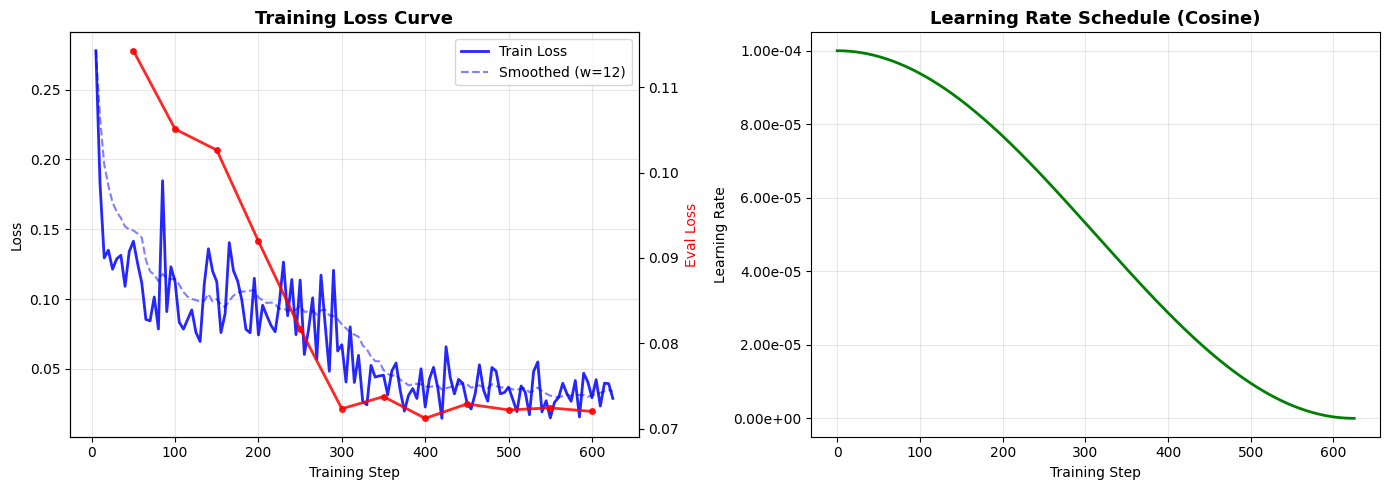

📊 Plot saved to /content/drive/MyDrive/NLU_Finetuning/plots/training_curves.png


In [39]:
# ─── Plot 1: Training & evaluation loss ───────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
if loss_tracker.train_losses:
    axes[0].plot(loss_tracker.train_steps, loss_tracker.train_losses,
                 "b-", linewidth=2, label="Train Loss", alpha=0.85)
    # Smooth with rolling mean
    if len(loss_tracker.train_losses) > 5:
        window = max(3, len(loss_tracker.train_losses) // 10)
        smooth = pd.Series(loss_tracker.train_losses).rolling(window, min_periods=1).mean()
        axes[0].plot(loss_tracker.train_steps, smooth,
                     "b--", linewidth=1.5, label=f"Smoothed (w={window})", alpha=0.5)
else:
    axes[0].text(0.5, 0.5, "No training data\n(run Section 7 first)",
                 ha="center", va="center", transform=axes[0].transAxes)

if loss_tracker.eval_losses:
    ax2 = axes[0].twinx()
    ax2.plot(loss_tracker.eval_steps, loss_tracker.eval_losses,
             "r-o", linewidth=2, markersize=4, label="Eval Loss", alpha=0.85)
    ax2.set_ylabel("Eval Loss", color="r")

axes[0].set_title("Training Loss Curve", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Training Step")
axes[0].set_ylabel("Loss")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

# Learning rate schedule (cosine)
if loss_tracker.train_steps:
    total_steps = max(loss_tracker.train_steps)
    steps = np.linspace(0, total_steps, 500)
    cosine_lr = [
        TRAIN_CONFIG["learning_rate"] * 0.5 *
        (1 + np.cos(np.pi * s / total_steps))
        for s in steps
    ]
    axes[1].plot(steps, cosine_lr, "g-", linewidth=2)
    axes[1].set_title("Learning Rate Schedule (Cosine)", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Training Step")
    axes[1].set_ylabel("Learning Rate")
    axes[1].grid(alpha=0.3)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2e}"))
else:
    axes[1].text(0.5, 0.5, "No step data available", ha="center", va="center",
                 transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(PLOT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"📊 Plot saved to {PLOT_DIR / 'training_curves.png'}")


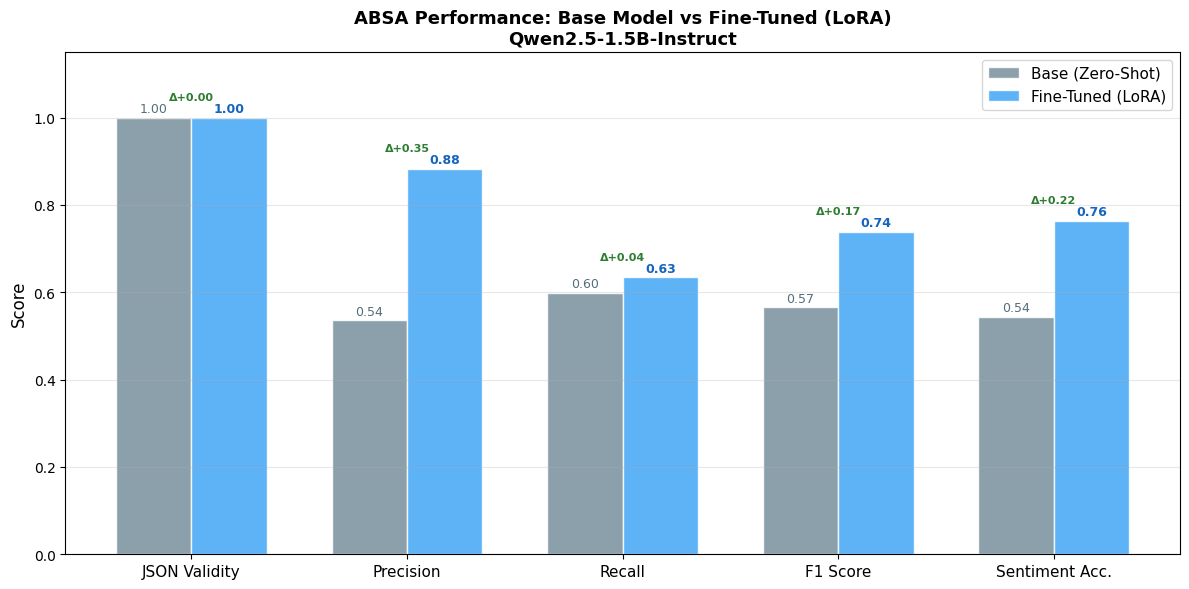

📊 Plot saved to /content/drive/MyDrive/NLU_Finetuning/plots/model_comparison.png


In [40]:
# ─── Plot 2: Before vs After comparison ───────────────────────────────────────

metric_names   = ["json_validity_rate", "precision", "recall", "f1", "sentiment_accuracy"]
metric_labels  = ["JSON Validity", "Precision", "Recall", "F1 Score", "Sentiment Acc."]

base_vals = [base_metrics[m] for m in metric_names]
ft_vals   = [ft_metrics[m]   for m in metric_names]

x     = np.arange(len(metric_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, base_vals, width, label="Base (Zero-Shot)",
               color="#78909C", alpha=0.85, edgecolor="white")
bars2 = ax.bar(x + width/2, ft_vals,   width, label="Fine-Tuned (LoRA)",
               color="#42A5F5", alpha=0.85, edgecolor="white")

# Annotations
for bar in bars1:
    ax.annotate(f"{bar.get_height():.2f}",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=9, color="#546E7A")
for bar in bars2:
    ax.annotate(f"{bar.get_height():.2f}",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=9, color="#1565C0", fontweight="bold")

# Delta arrows
for i, (b, ft) in enumerate(zip(base_vals, ft_vals)):
    delta = ft - b
    color = "#2E7D32" if delta >= 0 else "#C62828"
    ax.annotate(f"Δ{delta:+.2f}",
                xy=(x[i], max(b, ft) + 0.04),
                ha="center", fontsize=8, color=color, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("ABSA Performance: Base Model vs Fine-Tuned (LoRA)\nQwen2.5-1.5B-Instruct",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"📊 Plot saved to {PLOT_DIR / 'model_comparison.png'}")


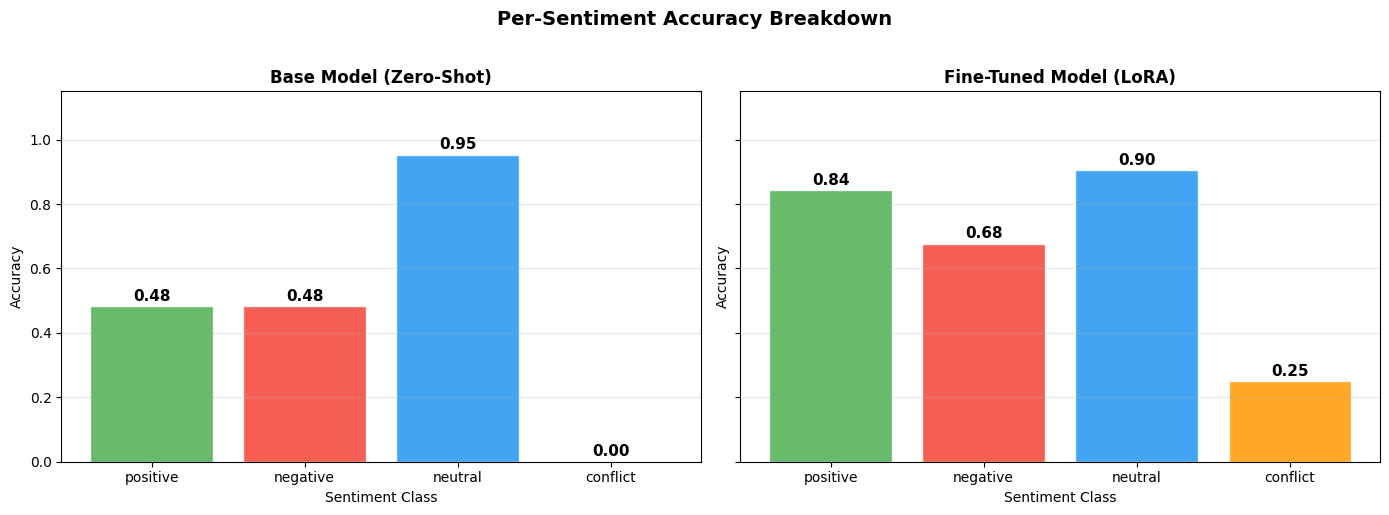

📊 Plot saved to /content/drive/MyDrive/NLU_Finetuning/plots/sentiment_breakdown.png


In [41]:
# ─── Plot 3: Per-sentiment accuracy breakdown ──────────────────────────────────

def compute_per_sentiment_accuracy(predictions, ground_truth):
    """Compute sentiment accuracy per class for matched terms."""
    from collections import defaultdict
    correct = defaultdict(int)
    total   = defaultdict(int)
    for pred_aspects, gold_aspects in zip(predictions, ground_truth):
        pred_map = {normalise_term(a["term"]): a["sentiment"] for a in pred_aspects}
        gold_map = {normalise_term(a["term"]): a["sentiment"] for a in gold_aspects}
        for term, gold_sent in gold_map.items():
            if term in pred_map:
                total[gold_sent]   += 1
                if pred_map[term] == gold_sent:
                    correct[gold_sent] += 1
    return {
        sent: correct[sent] / total[sent] if total[sent] > 0 else 0.0
        for sent in SENTIMENT_CLASSES
    }

base_per  = compute_per_sentiment_accuracy(base_metrics["predictions"], base_metrics["ground_truth"])
ft_per    = compute_per_sentiment_accuracy(ft_metrics["predictions"],   ft_metrics["ground_truth"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors_map = {"positive": "#4CAF50", "negative": "#F44336",
              "neutral": "#2196F3",  "conflict": "#FF9800"}

for ax, metrics, title in [
    (axes[0], base_per,  "Base Model (Zero-Shot)"),
    (axes[1], ft_per,    "Fine-Tuned Model (LoRA)"),
]:
    sents = list(metrics.keys())
    vals  = [metrics[s] for s in sents]
    clrs  = [colors_map.get(s, "#90A4AE") for s in sents]
    bars  = ax.bar(sents, vals, color=clrs, alpha=0.85, edgecolor="white")
    for bar in bars:
        ax.annotate(f"{bar.get_height():.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=11, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Sentiment Class")
    ax.set_ylabel("Accuracy")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Per-Sentiment Accuracy Breakdown", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR / "sentiment_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"📊 Plot saved to {PLOT_DIR / 'sentiment_breakdown.png'}")


## 14. Error Analysis

We systematically categorize prediction errors into three classes:

| Error Type | Description |
|---|---|
| **Missed Aspects** | Gold aspect present in review but not extracted by model |
| **Wrong Sentiment** | Aspect extracted correctly but wrong sentiment assigned |
| **Invalid JSON** | Model output could not be parsed as valid JSON |


In [42]:
# ─── Categorise errors ────────────────────────────────────────────────────────

def analyse_errors(
    predictions  : List[List[Dict]],
    ground_truth : List[List[Dict]],
    raw_outputs  : List[str],
    valid_flags  : List[bool],
    texts        : List[str],
    max_per_type : int = 5,
) -> Dict[str, List[Dict]]:
    """
    Categorise prediction errors into three buckets:
        - missed_aspects  : gold aspect not predicted
        - wrong_sentiment : aspect matched but wrong sentiment
        - invalid_json    : raw output is not valid JSON

    Returns a dict mapping error type → list of example records.
    """
    missed_aspects  = []
    wrong_sentiment = []
    invalid_json    = []

    for i, (pred_aspects, gold_aspects, raw, valid, text) in enumerate(
        zip(predictions, ground_truth, raw_outputs, valid_flags, texts)
    ):
        # ── Invalid JSON ────────────────────────────────────────────────────────
        if not valid:
            invalid_json.append({
                "review"    : text,
                "raw_output": raw,
                "gold"      : gold_aspects,
            })
            continue

        pred_map = {normalise_term(a["term"]): a["sentiment"] for a in pred_aspects}
        gold_map = {normalise_term(a["term"]): a["sentiment"] for a in gold_aspects}

        for term, gold_sent in gold_map.items():
            if term not in pred_map:
                # ── Missed aspect ───────────────────────────────────────────────
                missed_aspects.append({
                    "review"        : text,
                    "missed_term"   : term,
                    "gold_sentiment": gold_sent,
                    "predicted"     : pred_aspects,
                    "gold"          : gold_aspects,
                })
            elif pred_map[term] != gold_sent:
                # ── Wrong sentiment ─────────────────────────────────────────────
                wrong_sentiment.append({
                    "review"           : text,
                    "term"             : term,
                    "gold_sentiment"   : gold_sent,
                    "pred_sentiment"   : pred_map[term],
                    "predicted"        : pred_aspects,
                    "gold"             : gold_aspects,
                })

    return {
        "missed_aspects" : missed_aspects[:max_per_type],
        "wrong_sentiment": wrong_sentiment[:max_per_type],
        "invalid_json"   : invalid_json[:max_per_type],
    }


# Run on fine-tuned model predictions
error_analysis = analyse_errors(
    predictions  = ft_metrics["predictions"],
    ground_truth = ft_metrics["ground_truth"],
    raw_outputs  = ft_metrics["raw_outputs"],
    valid_flags  = ft_metrics["valid_flags"],
    texts        = test_df["text"].head(EVAL_SUBSET).tolist(),
)

# ─── Summary counts ────────────────────────────────────────────────────────────
n_invalid = sum(1 for v in ft_metrics["valid_flags"] if not v)
n_missed  = sum(
    len([t for t in r["gold"] if normalise_term(t["term"]) not in
         {normalise_term(p["term"]) for p in r["predicted"]}])
    for r in (ft_metrics.get("raw") or [])
) if False else "see below"

print("🔎 Error Analysis Summary (Fine-Tuned Model)")
print(f"   Total evaluated  : {EVAL_SUBSET}")
print(f"   Invalid JSON     : {n_invalid}  ({n_invalid / EVAL_SUBSET:.1%})")
print(f"   Missed Aspects   : {len(error_analysis['missed_aspects'])} shown (up to 5)")
print(f"   Wrong Sentiments : {len(error_analysis['wrong_sentiment'])} shown (up to 5)")

# Save error analysis
with open(OUTPUT_DIR / "error_analysis.json", "w") as f:
    json.dump(error_analysis, f, indent=2, default=str)
print(f"\n💾 Error analysis saved to {OUTPUT_DIR / 'error_analysis.json'}")


🔎 Error Analysis Summary (Fine-Tuned Model)
   Total evaluated  : 149
   Invalid JSON     : 0  (0.0%)
   Missed Aspects   : 5 shown (up to 5)
   Wrong Sentiments : 5 shown (up to 5)

💾 Error analysis saved to /content/drive/MyDrive/NLU_Finetuning/outputs/error_analysis.json


In [43]:
# ─── Display error examples ────────────────────────────────────────────────────

def print_error_section(title: str, errors: List[Dict], fields: List[Tuple[str, str]]):
    print(f"\n{'='*65}")
    print(f"  {title}  ({len(errors)} shown)")
    print(f"{'='*65}")
    if not errors:
        print("  None found — great!")
        return
    for i, err in enumerate(errors, 1):
        print(f"\n  Example {i}:")
        for key, label in fields:
            val = err.get(key, "N/A")
            if isinstance(val, list):
                val = json.dumps(val)
            print(f"    {label:<22}: {str(val)[:120]}")


print_error_section(
    "❌ MISSED ASPECTS",
    error_analysis["missed_aspects"],
    [
        ("review",         "Review"),
        ("missed_term",    "Missed Term"),
        ("gold_sentiment", "Gold Sentiment"),
        ("predicted",      "Predicted Aspects"),
        ("gold",           "Gold Aspects"),
    ]
)

print_error_section(
    "⚠️  WRONG SENTIMENT",
    error_analysis["wrong_sentiment"],
    [
        ("review",          "Review"),
        ("term",            "Aspect Term"),
        ("gold_sentiment",  "Gold Sentiment"),
        ("pred_sentiment",  "Predicted Sentiment"),
    ]
)

print_error_section(
    "🚫 INVALID JSON OUTPUT",
    error_analysis["invalid_json"],
    [
        ("review",     "Review"),
        ("raw_output", "Raw Output"),
    ]
)



  ❌ MISSED ASPECTS  (5 shown)

  Example 1:
    Review                : It started out by randomly ceasing to charge when it was plugged in (mousing over the battery icon would read, for examp
    Missed Term           : charging
    Gold Sentiment        : negative
    Predicted Aspects     : [{"term": "charge", "sentiment": "negative"}, {"term": "plugged in", "sentiment": "neutral"}]
    Gold Aspects          : [{"term": "charging", "sentiment": "negative"}, {"term": "charge", "sentiment": "negative"}, {"term": "charge", "sentime

  Example 2:
    Review                : This computer is exceptionally thin for it's screen size and processing power.
    Missed Term           : screen size
    Gold Sentiment        : positive
    Predicted Aspects     : [{"term": "processing power", "sentiment": "positive"}]
    Gold Aspects          : [{"term": "screen size", "sentiment": "positive"}, {"term": "processing power", "sentiment": "positive"}]

  Example 3:
    Review                : Nee

## 15. Final Summary & Saved Artifacts

In [44]:
# ─── Final results table ──────────────────────────────────────────────────────

summary = pd.DataFrame({
    "Metric": ["JSON Validity", "Precision", "Recall", "F1 Score", "Sentiment Acc."],
    "Base Model": [
        f"{base_metrics['json_validity_rate']:.2%}",
        f"{base_metrics['precision']:.2%}",
        f"{base_metrics['recall']:.2%}",
        f"{base_metrics['f1']:.2%}",
        f"{base_metrics['sentiment_accuracy']:.2%}",
    ],
    "Fine-Tuned (LoRA)": [
        f"{ft_metrics['json_validity_rate']:.2%}",
        f"{ft_metrics['precision']:.2%}",
        f"{ft_metrics['recall']:.2%}",
        f"{ft_metrics['f1']:.2%}",
        f"{ft_metrics['sentiment_accuracy']:.2%}",
    ],
    "Delta": [
        f"{(ft_metrics['json_validity_rate'] - base_metrics['json_validity_rate']):+.2%}",
        f"{(ft_metrics['precision'] - base_metrics['precision']):+.2%}",
        f"{(ft_metrics['recall'] - base_metrics['recall']):+.2%}",
        f"{(ft_metrics['f1'] - base_metrics['f1']):+.2%}",
        f"{(ft_metrics['sentiment_accuracy'] - base_metrics['sentiment_accuracy']):+.2%}",
    ],
})

print("\n🏆 FINAL RESULTS")
print("=" * 70)
print(summary.to_string(index=False))

# ─── Artifacts inventory ───────────────────────────────────────────────────────
print("\n\n📦 Saved Artifacts:")
for p in sorted(BASE_DIR.rglob("*")):
    if p.is_file():
        size_kb = p.stat().st_size / 1024
        print(f"   {str(p):<60} {size_kb:>8.1f} KB")


🏆 FINAL RESULTS
        Metric Base Model Fine-Tuned (LoRA)   Delta
 JSON Validity    100.00%           100.00%  +0.00%
     Precision     53.54%            88.34% +34.80%
        Recall     59.91%            63.44%  +3.53%
      F1 Score     56.55%            73.85% +17.30%
Sentiment Acc.     54.41%            76.39% +21.98%


📦 Saved Artifacts:
   /content/drive/MyDrive/NLU_Finetuning/Laptop_Train_v2.csv       315.6 KB


In [46]:
# ─── Interactive inference demo ───────────────────────────────────────────────
print("🎯 Interactive Inference Demo")
print("=" * 70)

demo_reviews = [
    "The display is gorgeous with deep blacks, but the keyboard flex is disappointing.",
    "I charge it at night and skip taking the cord with me because of the good battery life.",
    "RAM is more than enough for multitasking and the SSD speed is blazing fast.",
    "The build quality feels premium but the trackpad is a bit mushy and imprecise.",
    "Fan noise is acceptable under light loads but gets very loud during gaming.",
]

for review in demo_reviews:
    result = predict_absa(review)
    print(f"\n📝 Review  : {review}")
    print(f"   ✅ Valid : {result['valid']}")
    if result["valid"]:
        for asp in result["aspects"]:
            emoji = {"positive": "🟢", "negative": "🔴",
                     "neutral": "🔵", "conflict": "🟠"}.get(asp["sentiment"], "⚪")
            print(f"   {emoji} {asp['term']:<25} → {asp['sentiment']}")
    else:
        print(f"   ❌ Error : {result['error']}")


🎯 Interactive Inference Demo

📝 Review  : The display is gorgeous with deep blacks, but the keyboard flex is disappointing.
   ✅ Valid : True
   🟢 display                   → positive
   🔴 keyboard                  → negative

📝 Review  : I charge it at night and skip taking the cord with me because of the good battery life.
   ✅ Valid : True
   🔵 cord                      → neutral

📝 Review  : RAM is more than enough for multitasking and the SSD speed is blazing fast.
   ✅ Valid : True
   🟢 RAM                       → positive
   🟢 SSD speed                 → positive

📝 Review  : The build quality feels premium but the trackpad is a bit mushy and imprecise.
   ✅ Valid : True
   🔴 trackpad                  → negative

📝 Review  : Fan noise is acceptable under light loads but gets very loud during gaming.
   ✅ Valid : True
   🟠 Fan noise                 → conflict


In [47]:
import os
from peft import PeftModel

# ── 1. Save LoRA adapter weights (small, ~70MB) ──────────────────────────────
ADAPTER_DIR = str(MODEL_DIR / "Final_Version" / "qwen_absa_lora")
model.save_pretrained(ADAPTER_DIR)
print(f"✅ LoRA adapter saved to {ADAPTER_DIR}")

# ── 2. Save tokenizer ─────────────────────────────────────────────────────────
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"✅ Tokenizer saved to {ADAPTER_DIR}")

# ── 3. Verify what was saved ──────────────────────────────────────────────────
for f in sorted(os.listdir(ADAPTER_DIR)):
    size = os.path.getsize(os.path.join(ADAPTER_DIR, f)) / 1e6
    print(f"   {f:45s} {size:.1f} MB")

✅ LoRA adapter saved to /content/drive/MyDrive/NLU_Finetuning/model/Final_Version/qwen_absa_lora
✅ Tokenizer saved to /content/drive/MyDrive/NLU_Finetuning/model/Final_Version/qwen_absa_lora
   README.md                                     0.0 MB
   adapter_config.json                           0.0 MB
   adapter_model.safetensors                     73.9 MB
   added_tokens.json                             0.0 MB
   merges.txt                                    1.7 MB
   special_tokens_map.json                       0.0 MB
   tokenizer_config.json                         0.0 MB
   vocab.json                                    3.4 MB


In [ ]:
!pip install -q gradio fastapi uvicorn
import sys

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.4/462.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 61.3 MB/s eta 0:00:00


In [ ]:
sys.path.insert(0, "/content/absa_api")

In [ ]:
from inference import predict
result = predict("The trackpad is smooth but the display has terrible color accuracy.")
print(result)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

{'aspects': [{'term': 'trackpad', 'sentiment': 'positive'}, {'term': 'display', 'sentiment': 'negative'}], 'raw_output': '{"aspects":[{"term":"trackpad","sentiment":"positive"},{"term":"display","sentiment":"negative"}]}', 'valid': True, 'error': None}
